# Predicting Future High-Value Physician–Industry Relationships Among Nephrologists Using CMS Open Payments Data

### Capstone Project

**Author:** Colleen Yap  
**Program:** Professional Certificate in Machine Learning & Artificial Intelligence


# Table of Contents

1. Introduction
   - 1.1 Project Overview
   - 1.2 Business Problem
   - 1.3 Research Question
   - 1.4 Dataset
   - 1.5 Methodology
   - 1.6 Expected Outcomes
   - 1.7 Significance of the Study

2. Data Engineering
   - 2.1 Data Pipeline
   - 2.2 Data Engineering Analysis

3. Exploratory Data Analysis (EDA)
   - 3.1 Load Final Modeling Dataset (from SQL Server)
   - 3.2 Dataset Overview
   - 3.3 Dataset Dimensions and Information
   - 3.4 Data Types
   - 3.5 Missing Values and Duplicate Records
   - 3.6 Summary Statistics
   - 3.7 Target Distribution
   - 3.8 Historical Consulting Payment Distribution
   - 3.9 Payment Type Comparison
   - 3.10 High-Value vs. Non-High-Value Physicians
   - 3.11 Correlation Analysis
   - 3.12 Geographic Distribution
   - 3.13 Active Years Distribution
   - 3.14 EDA Summary

4. Data Preparation
   - 4.1 Reload and Verify Modeling Dataset
   - 4.2 Inspect Columns
   - 4.3 Check Data Types
   - 4.4 Define Target Variable
   - 4.5 Define Predictor Variables
   - 4.6 Identify Numerical and Categorical Features
   - 4.7 Encode Categorical Features
   - 4.8 Train/Test Split
   - 4.9 Standardize Numerical Features

5. Machine Learning Model Development
   - 5.1 Logistic Regression Baseline
   - 5.2 Decision Tree
   - 5.3 Random Forest
   - 5.4 Gradient Boosting

6. Model Evaluation
   - 6.1 Store Model Metrics
   - 6.2 Model Performance Comparison
   - 6.3 ROC Curve Comparison
   - 6.4 Final Model Selection
   - 6.5 Gradient Boosting Feature Importance

7. Prediction Validation
   - 7.1 Generate Final Physician Predictions
   - 7.2 Top-Decile Lift Analysis
   - 7.3 Precision@100
   - 7.4 Ranking Validation Against Actual 2024 High-Value Physicians
   - 7.5 Prediction Outcome Analysis

8. Results and Discussion

9. Conclusion


# 1. Introduction


## 1.1 Project Overview

This project examines whether historical physician–industry payment activity can be used to predict which nephrologists will be classified as high-value physicians in the following year. Using publicly available CMS Open Payments data, I created physician-level features from payment records between 2020 and 2023, including consulting activity, speaking and honoraria payments, travel support, payment frequency, active years, and the breadth of company and product relationships. These historical features were used to predict high-value physician status in 2024.

Four classification models were developed and compared: Logistic Regression, Decision Tree, Random Forest, and Gradient Boosting. The models were evaluated using accuracy, precision, recall, F1-score, ROC-AUC, confusion matrices, and ROC curves. Gradient Boosting produced the strongest overall performance.

The project demonstrates that CMS Open Payments data can support predictive analysis in addition to historical reporting. The resulting model is intended as a ranking and prioritization tool that may help identify nephrologists whose historical payment patterns resemble those of physicians who later received high-value payments.


## 1.2 Business Problem

The CMS Open Payments program provides transparency into financial relationships between physicians and life sciences companies. Although these data are publicly available, they are primarily used for historical reporting and compliance.

Organizations interested in understanding physician engagement often rely on prior payment reports or existing CRM data. These sources may not clearly identify physicians whose engagement patterns are changing over time. A predictive approach can help rank physicians according to their likelihood of becoming high value, providing an additional analytical input for commercial and medical affairs planning.

This project evaluates whether historical physician-industry payment activity can be used to predict future high-value physician status among nephrologists.


## 1.3 Research Question

Can historical physician–industry payment patterns from 2020-2023 bold text be used to predict which nephrologists will receive high-value industry payments in 2024?

A physician is considered high value when total 2024 General Payments are at or above the 90th percentile of the 2024 nephrology payment population.


## 1.4 Dataset

The primary data source is the **CMS Open Payments General Payments** database maintained by the Centers for Medicare & Medicaid Services (CMS):

https://openpaymentsdata.cms.gov/

The analysis includes General Payments records from **2020 through 2024** for physicians whose specialty is nephrology. Historical data from **2020–2023** were used to create physician-level predictor variables. The **2024** data were used to construct the binary target and evaluate model performance.


## 1.5 Methodology

The project uses an end-to-end analytical workflow:

- SQL data cleaning, integration, aggregation, and feature engineering in SQL Server Management Studio (SSMS)
- Exploratory data analysis in Python using pandas, NumPy, and Matplotlib
- Classification models including Logistic Regression, Decision Tree, Random Forest, and Gradient Boosting
- Model evaluation using accuracy, precision, recall, F1-score, ROC-AUC, confusion matrices, and ROC curves
- Feature importance analysis for the selected model
- Ranking validation to compare predicted physicians with actual 2024 high-value physicians

Multiple classification algorithms were evaluated to compare predictive performance and identify the most appropriate model for predicting future high-value physician status.


## 1.6 Expected Outcomes

The analysis is expected to identify historical physician–industry payment patterns associated with future high-value physician status. The model classifies physicians into two groups: **high value** and **not high value**. It does not estimate payment tiers or exact future payment amounts.

The project also evaluates which historical characteristics contribute most to the predictions and compares predicted outcomes with actual 2024 labels using standard classification and ranking metrics.


## 1.7 Significance of the Study

CMS Open Payments provides a detailed record of historical financial relationships between physicians and life sciences companies. This project explores whether those historical records also contain useful signals about future physician–industry engagement.

For organizations developing kidney disease therapies, a ranked view of physicians with a higher likelihood of future high-value status may support further review, engagement planning, educational initiatives, and partnership discussions. The model is not intended to replace professional judgment or existing CRM processes. Instead, it provides an additional data-driven perspective that can be evaluated alongside other commercial and medical information.

Comparison with internal CRM data is outside the scope of this capstone, but it could be considered as a future extension.


# 2. Data Engineering

The raw CMS data contained millions of individual payment records. Five annual General Payments datasets were combined, filtered to nephrologists, and aggregated into physician-year summaries. Those annual summaries were then transformed into one historical physician profile per physician using data from 2020–2023. The resulting historical features were joined to the 2024 target to create the final modeling dataset.

Transaction-level records were aggregated into physician-level historical features to capture longer-term payment behavior, reduce data dimensionality, and preserve temporal separation between the predictors and outcome.


## 2.1 Data Pipeline

The CMS Open Payments data were transformed through a multi-step pipeline to create the physician-level machine learning dataset.

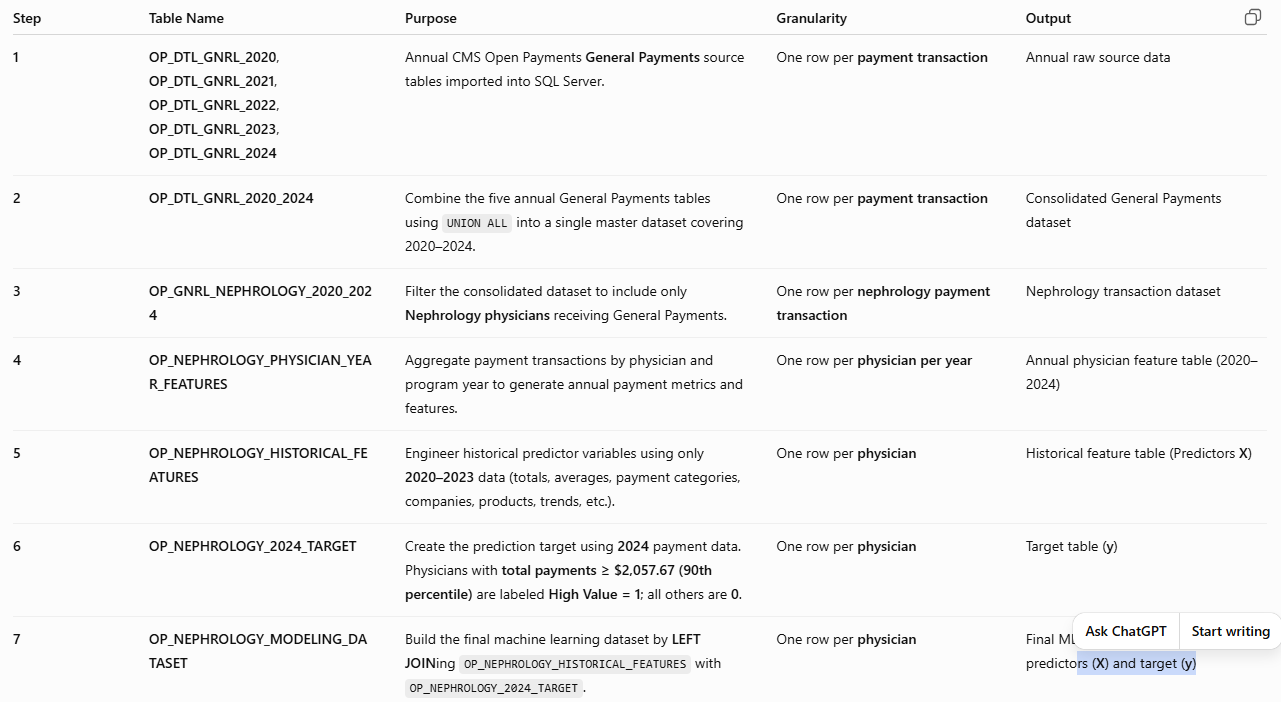

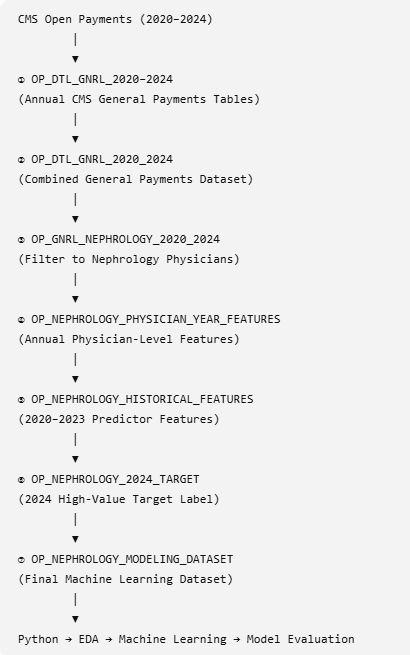


This data engineering process transformed transaction-level payment records into a physician-level analytical dataset. Historical payment patterns from 2020-2023 were used as predictor variables, while actual payment outcomes from 2024 served as the target for model training and evaluation.

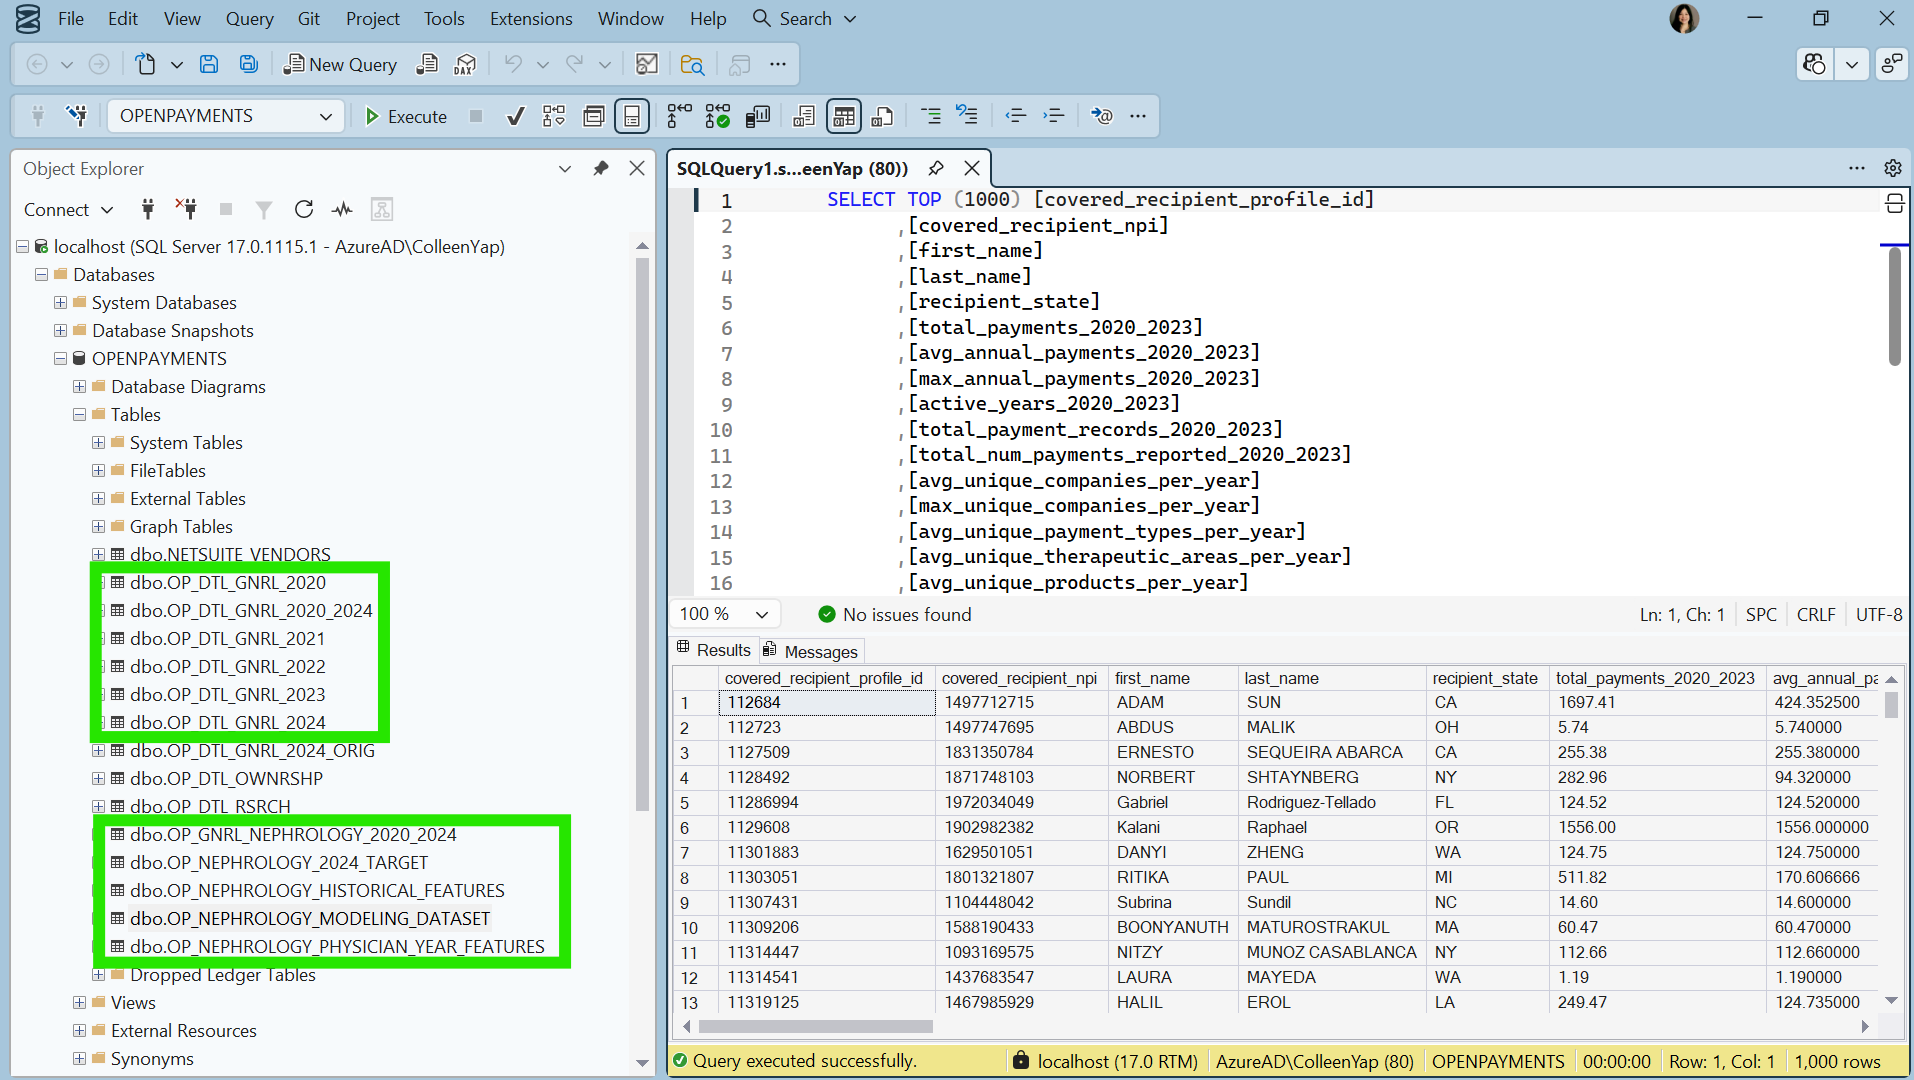


## 2.2 Data Engineering Analysis

A structured data engineering pipeline transformed raw CMS Open Payments transactions into a physician-level dataset suitable for predictive modeling. The pipeline integrated five years of General Payments data (2020-2024), filtered records to nephrology physicians, and created historical features describing payment behavior from 2020-2023.


The 2024 target population included **8,694 nephrologists**, with payments ranging from $00.37 to $762,590.52 and an average payment of $2,858.47.

Because the distribution was highly right-skewed, physicians whose 2024 payments were at or above the **90th percentile ($2,057.67)** were labeled high value. This represented **870 physicians (10.01%)** within the 2024 payment population.

The final modeling dataset contained **11,044 physicians** because the historical feature table also included physicians with activity during 2020-2023 who had no matching 2024 payment record. These physicians were assigned a 2024 payment value of zero and a non-high-value label. As a result, the positive class represented approximately **7.88%** of the final modeling dataset.

By separating historical predictor variables from the 2024 outcome, the pipeline preserves chronological order, reduces target leakage, and provides a reliable foundation for predictive modeling.


# 3. Exploratory Data Analysis (EDA)

This section examines the structure, quality, distributions, and relationships in the final physician-level modeling dataset.


In [1]:
# Step 3.1 — Load Final Modeling Dataset

from google.colab import files
uploaded = files.upload()


Saving OP_NEPHROLOGY_MODELING_DATASET_USETHIS.csv to OP_NEPHROLOGY_MODELING_DATASET_USETHIS.csv


In [2]:
# Step 3.2 — Dataset Overview

import pandas as pd

df = pd.read_csv(
    "OP_NEPHROLOGY_MODELING_DATASET_USETHIS.csv",
    encoding="utf-8-sig"
)

print("Dataset shape:", df.shape)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

print(df.columns.tolist())

print("First five records:")
display(df.head())

print("\nRandom sample:")
display(df.sample(5, random_state=42))


Dataset shape: (11044, 24)
Rows: 11044
Columns: 24
['covered_recipient_profile_id', 'covered_recipient_npi', 'first_name', 'last_name', 'recipient_state', 'total_payments_2020_2023', 'avg_annual_payments_2020_2023', 'max_annual_payments_2020_2023', 'active_years_2020_2023', 'total_payment_records_2020_2023', 'total_num_payments_reported_2020_2023', 'avg_unique_companies_per_year', 'max_unique_companies_per_year', 'avg_unique_payment_types_per_year', 'avg_unique_therapeutic_areas_per_year', 'avg_unique_products_per_year', 'consulting_payments_2020_2023', 'speaker_or_honoraria_payments_2020_2023', 'travel_lodging_payments_2020_2023', 'food_beverage_payments_2020_2023', 'consulting_payment_ratio', 'speaker_or_honoraria_payment_ratio', 'total_payments_2024', 'high_value_2024']
First five records:


,covered_recipient_profile_id,covered_recipient_npi,first_name,last_name,recipient_state,total_payments_2020_2023,avg_annual_payments_2020_2023,max_annual_payments_2020_2023,active_years_2020_2023,total_payment_records_2020_2023,...,avg_unique_therapeutic_areas_per_year,avg_unique_products_per_year,consulting_payments_2020_2023,speaker_or_honoraria_payments_2020_2023,travel_lodging_payments_2020_2023,food_beverage_payments_2020_2023,consulting_payment_ratio,speaker_or_honoraria_payment_ratio,total_payments_2024,high_value_2024
0,112684,1.497713e+09,ADAM,SUN,CA,1697.41,424.3525,655.73,4,71,...,5.000000,7.750000,0.0,0.0,0.0,1638.42,0.0,0.0,772.37,0
1,112723,1.497748e+09,ABDUS,MALIK,OH,5.74,5.7400,5.74,1,2,...,0.000000,0.000000,0.0,0.0,0.0,0.00,0.0,0.0,3.08,0
2,1127509,1.831351e+09,ERNESTO,SEQUEIRA ABARCA,CA,255.38,255.3800,255.38,1,14,...,7.000000,8.000000,0.0,0.0,0.0,255.38,0.0,0.0,586.77,0
3,1128492,1.871748e+09,NORBERT,SHTAYNBERG,NY,282.96,94.3200,146.91,3,6,...,1.333333,1.333333,0.0,0.0,0.0,282.96,0.0,0.0,396.60,0
4,11286994,1.972034e+09,Gabriel,Rodriguez-Tellado,FL,124.52,124.5200,124.52,1,1,...,1.000000,1.000000,0.0,0.0,0.0,124.52,0.0,0.0,0.00,0



Random sample:


,covered_recipient_profile_id,covered_recipient_npi,first_name,last_name,recipient_state,total_payments_2020_2023,avg_annual_payments_2020_2023,max_annual_payments_2020_2023,active_years_2020_2023,total_payment_records_2020_2023,...,avg_unique_therapeutic_areas_per_year,avg_unique_products_per_year,consulting_payments_2020_2023,speaker_or_honoraria_payments_2020_2023,travel_lodging_payments_2020_2023,food_beverage_payments_2020_2023,consulting_payment_ratio,speaker_or_honoraria_payment_ratio,total_payments_2024,high_value_2024
3938,227104,1.013070e+09,Eric,Holt,MS,544.18,181.393333,300.86,3,19,...,1.333333,2.00,0.0,0.0,0.0,544.18,0.000000,0.0,426.63,0
9941,762159,1.003816e+09,Grace,Grant-Jennings,TX,24.74,24.740000,24.74,1,1,...,0.000000,0.00,0.0,0.0,0.0,24.74,0.000000,0.0,0.00,0
5338,356282,1.841238e+09,Chaitali,Dey,NJ,3143.12,1047.706666,2128.66,3,56,...,4.000000,4.00,1575.0,0.0,0.0,1568.12,0.501094,0.0,674.03,0
5344,357174,1.861403e+09,Adel,El-hennawy,NY,976.41,244.102500,470.47,4,42,...,3.000000,3.25,0.0,0.0,0.0,976.41,0.000000,0.0,216.28,0
1623,1175885,1.548464e+09,ANNA,BURGNER,TN,9333.70,2333.425000,6000.00,4,14,...,0.250000,0.75,9300.0,0.0,0.0,0.00,0.996389,0.0,3.08,0


In [ ]:
# Step 3.3 — Dataset Dimensions and Information

rows, columns = df.shape

print(f"Number of physician records: {rows:,}")
print(f"Number of columns: {columns}")
print(f"Dataset dimensions: {df.shape}")
df.info()


Number of physician records: 11,044
Number of columns: 24
Dataset dimensions: (11044, 24)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11044 entries, 0 to 11043
Data columns (total 24 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   covered_recipient_profile_id             11044 non-null  int64  
 1   covered_recipient_npi                    11037 non-null  float64
 2   first_name                               11044 non-null  object 
 3   last_name                                11044 non-null  object 
 4   recipient_state                          11043 non-null  object 
 5   total_payments_2020_2023                 11044 non-null  float64
 6   avg_annual_payments_2020_2023            11044 non-null  float64
 7   max_annual_payments_2020_2023            11044 non-null  float64
 8   active_years_2020_2023                   11044 non-null  int64  
 9   total_payment_records_2020

In [ ]:
# Step 3.4 — Data Types

print("Dataset information:")
df.info()

print("\nData types by column:")
display(
    df.dtypes
      .astype(str)
      .reset_index()
      .rename(columns={
          "index": "column_name",
          0: "data_type"
      })
)


Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11044 entries, 0 to 11043
Data columns (total 24 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   covered_recipient_profile_id             11044 non-null  int64  
 1   covered_recipient_npi                    11037 non-null  float64
 2   first_name                               11044 non-null  object 
 3   last_name                                11044 non-null  object 
 4   recipient_state                          11043 non-null  object 
 5   total_payments_2020_2023                 11044 non-null  float64
 6   avg_annual_payments_2020_2023            11044 non-null  float64
 7   max_annual_payments_2020_2023            11044 non-null  float64
 8   active_years_2020_2023                   11044 non-null  int64  
 9   total_payment_records_2020_2023          11044 non-null  int64  
 10  total_num_payments_report

,column_name,data_type
0,covered_recipient_profile_id,int64
1,covered_recipient_npi,float64
2,first_name,object
3,last_name,object
4,recipient_state,object
5,total_payments_2020_2023,float64
6,avg_annual_payments_2020_2023,float64
7,max_annual_payments_2020_2023,float64
8,active_years_2020_2023,int64
9,total_payment_records_2020_2023,int64


In [ ]:
# Step 3.5 — Missing Values and Duplicate Records

missing_values = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percentage": (df.isnull().mean() * 100).round(2)
}).sort_values("missing_count", ascending=False)

display(missing_values)
print(f"Total missing values in dataset: {df.isnull().sum().sum():,}")

columns_with_missing = missing_values[
    missing_values["missing_count"] > 0
]

if columns_with_missing.empty:
    print("No missing values were found.")
else:
    print("Columns containing missing values:")
    display(columns_with_missing)

# Duplicate checks are performed regardless of whether missing values exist
duplicate_physicians = df.duplicated(
    subset="covered_recipient_profile_id"
).sum()

duplicate_rows = df.duplicated().sum()

print(f"Duplicate physician IDs: {duplicate_physicians:,}")
print(f"Completely duplicated rows: {duplicate_rows:,}")


,missing_count,missing_percentage
covered_recipient_npi,7,0.06
recipient_state,1,0.01
first_name,0,0.00
covered_recipient_profile_id,0,0.00
last_name,0,0.00
total_payments_2020_2023,0,0.00
avg_annual_payments_2020_2023,0,0.00
max_annual_payments_2020_2023,0,0.00
active_years_2020_2023,0,0.00
total_payment_records_2020_2023,0,0.00


Total missing values in dataset: 8
Columns containing missing values:


,missing_count,missing_percentage
covered_recipient_npi,7,0.06
recipient_state,1,0.01


Duplicate physician IDs: 0
Completely duplicated rows: 0


In [ ]:

# Step 3.6 — Summary Statistics

summary_statistics = df.describe().T

display(summary_statistics)

# payment columns, summary
payment_columns = [
    "total_payments_2020_2023",
    "avg_annual_payments_2020_2023",
    "max_annual_payments_2020_2023",
    "consulting_payments_2020_2023",
    "speaker_or_honoraria_payments_2020_2023",
    "travel_lodging_payments_2020_2023",
    "food_beverage_payments_2020_2023",
    "total_payments_2024"
]

payment_summary = (
    df[payment_columns]
    .describe()
    .T
    .round(2)
)

display(payment_summary)

# 2024 payment median
print(
    "2024 minimum payment:",
    f"${df['total_payments_2024'].min():,.2f}"
)

print(
    "2024 median payment:",
    f"${df['total_payments_2024'].median():,.2f}"
)

print(
    "2024 average payment:",
    f"${df['total_payments_2024'].mean():,.2f}"
)

print(
    "2024 maximum payment:",
    f"${df['total_payments_2024'].max():,.2f}"
)


,count,mean,std,min,25%,50%,75%,max
covered_recipient_profile_id,11044.0,1.540768e+06,2.665054e+06,2.500000e+01,2.232950e+05,5.846255e+05,1.196265e+06,1.168109e+07
covered_recipient_npi,11037.0,1.501394e+09,2.875532e+08,1.003004e+09,1.255341e+09,1.497860e+09,1.750359e+09,1.992992e+09
total_payments_2020_2023,11044.0,1.031090e+04,2.579509e+05,1.010000e+00,1.066225e+02,3.747850e+02,1.553303e+03,1.877793e+07
avg_annual_payments_2020_2023,11044.0,2.803661e+03,6.486654e+04,1.010000e+00,5.735375e+01,1.445850e+02,4.448352e+02,4.694482e+06
max_annual_payments_2020_2023,11044.0,6.682200e+03,2.532425e+05,1.010000e+00,8.039000e+01,2.226800e+02,7.106750e+02,1.875543e+07
active_years_2020_2023,11044.0,2.687613e+00,1.222886e+00,1.000000e+00,1.000000e+00,3.000000e+00,4.000000e+00,4.000000e+00
total_payment_records_2020_2023,11044.0,3.742466e+01,7.613125e+01,1.000000e+00,2.000000e+00,9.000000e+00,3.900000e+01,1.429000e+03
total_num_payments_reported_2020_2023,11044.0,3.863745e+01,7.887251e+01,1.000000e+00,2.000000e+00,9.000000e+00,4.100000e+01,1.430000e+03
avg_unique_companies_per_year,11044.0,3.720791e+00,3.702103e+00,1.000000e+00,1.000000e+00,2.000000e+00,5.000000e+00,3.300000e+01
max_unique_companies_per_year,11044.0,5.091815e+00,5.020062e+00,1.000000e+00,1.000000e+00,3.000000e+00,8.000000e+00,3.800000e+01


,count,mean,std,min,25%,50%,75%,max
total_payments_2020_2023,11044.0,10310.90,257950.85,1.01,106.62,374.78,1553.30,18777927.11
avg_annual_payments_2020_2023,11044.0,2803.66,64866.54,1.01,57.35,144.58,444.84,4694481.78
max_annual_payments_2020_2023,11044.0,6682.20,253242.52,1.01,80.39,222.68,710.68,18755427.50
consulting_payments_2020_2023,11044.0,4803.17,44443.35,0.00,0.00,0.00,0.00,2161761.18
speaker_or_honoraria_payments_2020_2023,11044.0,3120.93,26721.33,0.00,0.00,0.00,0.00,998546.13
travel_lodging_payments_2020_2023,11044.0,508.26,5913.13,0.00,0.00,0.00,0.00,440889.19
food_beverage_payments_2020_2023,11044.0,847.94,1776.14,0.00,69.46,260.64,954.21,79453.79
total_payments_2024,11044.0,2224.98,15255.23,0.00,0.00,117.52,534.35,762590.52


2024 minimum payment: $0.00
2024 median payment: $117.52
2024 average payment: $2,224.98
2024 maximum payment: $762,590.52


,high_value_2024,classification,physician_count,percentage
0,0,Non-High Value,10195,92.31
1,1,High Value,849,7.69


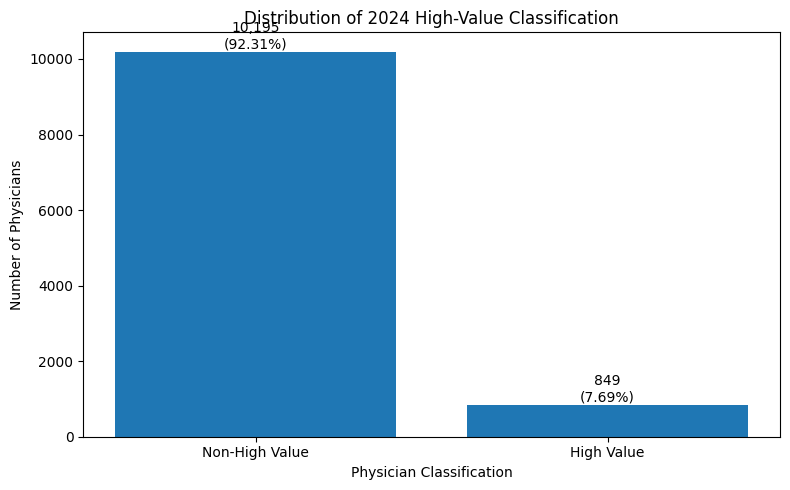

In [ ]:
# Step 3.7 — Target Distribution

import matplotlib.pyplot as plt
import seaborn as sns

target_counts = (
    df["high_value_2024"]
    .value_counts()
    .sort_index()
)

target_percentages = (
    df["high_value_2024"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

target_distribution = pd.DataFrame({
    "high_value_2024": target_counts.index,
    "physician_count": target_counts.values,
    "percentage": target_percentages.values.round(2)
})

target_distribution["classification"] = (
    target_distribution["high_value_2024"]
    .map({
        0: "Non-High Value",
        1: "High Value"
    })
)

display(
    target_distribution[
        [
            "high_value_2024",
            "classification",
            "physician_count",
            "percentage"
        ]
    ]
)

# Target Distribution Chart
plt.figure(figsize=(8, 5))

bars = plt.bar(
    target_distribution["classification"],
    target_distribution["physician_count"]
)

plt.title("Distribution of 2024 High-Value Classification")
plt.xlabel("Physician Classification")
plt.ylabel("Number of Physicians")

for bar, count, percentage in zip(
    bars,
    target_distribution["physician_count"],
    target_distribution["percentage"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}\n({percentage:.2f}%)",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


In [ ]:
# Step 3.8 — Historical Consulting Payment Distribution

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

consulting = df["consulting_payments_2020_2023"]

print("Historical consulting payment summary:")
display(consulting.describe().round(2))


Historical consulting payment summary:


,consulting_payments_2020_2023
count,11044.00
mean,4803.17
std,44443.35
min,0.00
25%,0.00
50%,0.00
75%,0.00
max,2161761.18


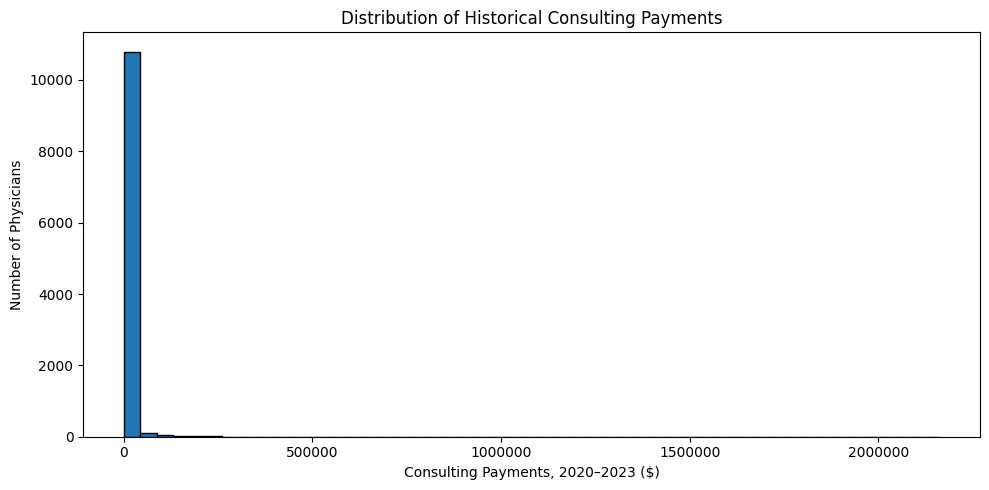

In [ ]:
# Original scale histogram
plt.figure(figsize=(10, 5))

plt.hist(
    consulting,
    bins=50,
    edgecolor="black"
)

plt.title("Distribution of Historical Consulting Payments")
plt.xlabel("Consulting Payments, 2020–2023 ($)")
plt.ylabel("Number of Physicians")

plt.ticklabel_format(
    style="plain",
    axis="x"
)

plt.tight_layout()
plt.show()


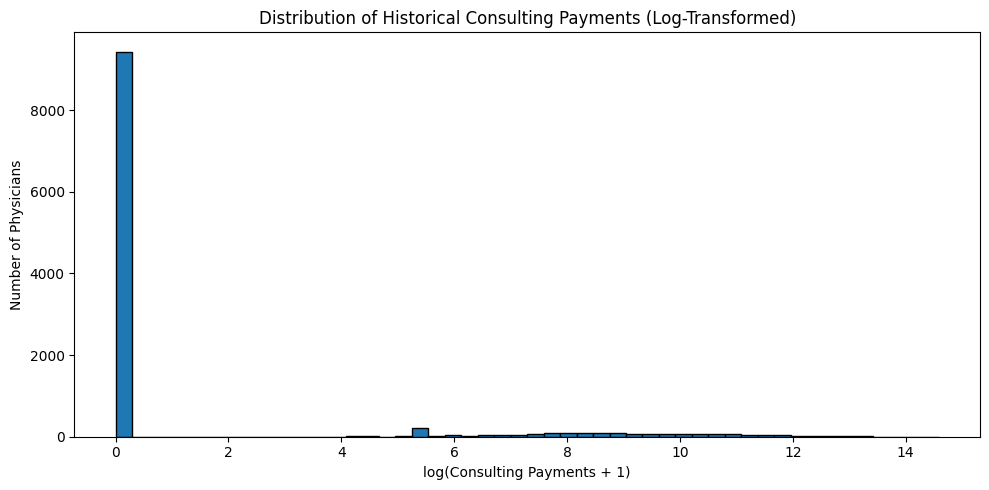

In [ ]:

# Log transformed histogram
plt.figure(figsize=(10, 5))

plt.hist(
    np.log1p(consulting),
    bins=50,
    edgecolor="black"
)

plt.title(
    "Distribution of Historical Consulting Payments "
    "(Log-Transformed)"
)
plt.xlabel("log(Consulting Payments + 1)")
plt.ylabel("Number of Physicians")

plt.tight_layout()
plt.show()


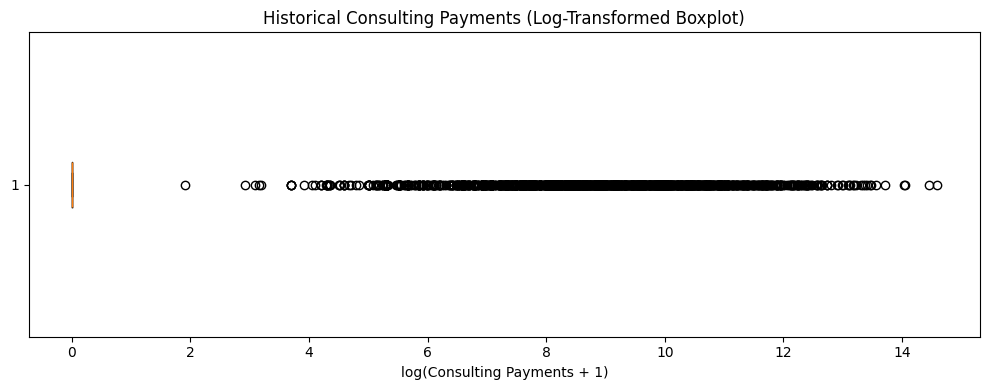

In [ ]:

# Boxplot
plt.figure(figsize=(10, 4))

plt.boxplot(
    np.log1p(consulting),
    vert=False
)

plt.title(
    "Historical Consulting Payments "
    "(Log-Transformed Boxplot)"
)
plt.xlabel("log(Consulting Payments + 1)")

plt.tight_layout()
plt.show()


In [ ]:
# Step 3.9 — Payment Type Comparison

payment_type_columns = {
    "Consulting":
        "consulting_payments_2020_2023",

    "Speaker or Honoraria":
        "speaker_or_honoraria_payments_2020_2023",

    "Travel and Lodging":
        "travel_lodging_payments_2020_2023",

    "Food and Beverage":
        "food_beverage_payments_2020_2023"
}

payment_type_summary = pd.DataFrame({
    "payment_type": payment_type_columns.keys(),
    "total_payment_amount": [
        df[column].sum()
        for column in payment_type_columns.values()
    ],
    "median_per_physician": [
        df[column].median()
        for column in payment_type_columns.values()
    ],
    "mean_per_physician": [
        df[column].mean()
        for column in payment_type_columns.values()
    ],
    "physicians_with_payment": [
        (df[column] > 0).sum()
        for column in payment_type_columns.values()
    ]
})

payment_type_summary = (
    payment_type_summary
    .sort_values(
        "total_payment_amount",
        ascending=False
    )
)

display(
    payment_type_summary.style.format({
        "total_payment_amount": "${:,.2f}",
        "median_per_physician": "${:,.2f}",
        "mean_per_physician": "${:,.2f}",
        "physicians_with_payment": "{:,.0f}"
    })
)


,payment_type,total_payment_amount,median_per_physician,mean_per_physician,physicians_with_payment
0,Consulting,"$53,046,183.08",$0.00,"$4,803.17","1,609"
1,Speaker or Honoraria,"$34,467,520.35",$0.00,"$3,120.93","1,229"
3,Food and Beverage,"$9,364,629.05",$260.64,$847.94,"10,384"
2,Travel and Lodging,"$5,613,254.06",$0.00,$508.26,961


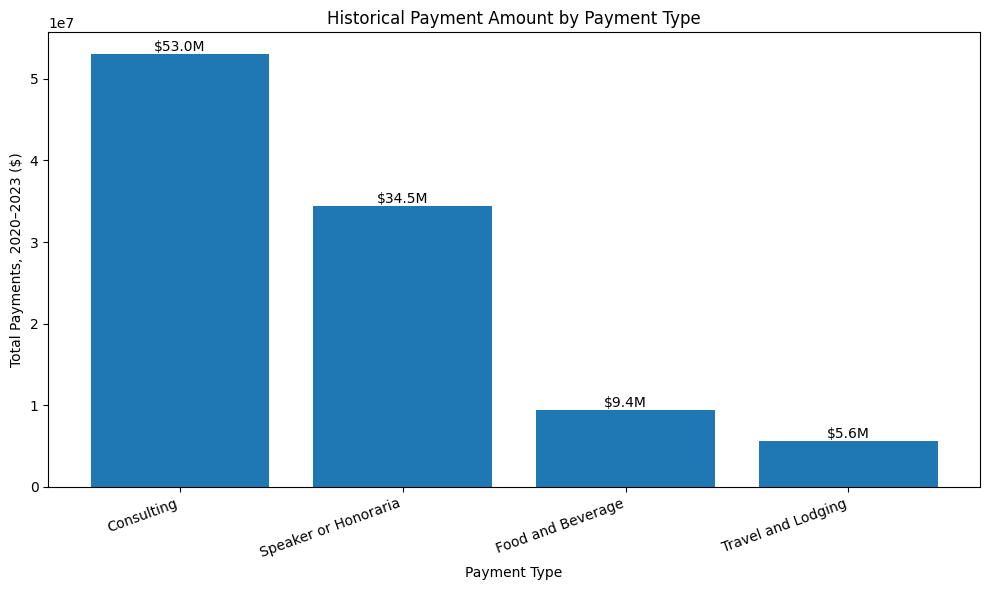

In [ ]:
# Payment type chart
plt.figure(figsize=(10, 6))

bars = plt.bar(
    payment_type_summary["payment_type"],
    payment_type_summary["total_payment_amount"]
)

plt.title("Historical Payment Amount by Payment Type")
plt.xlabel("Payment Type")
plt.ylabel("Total Payments, 2020–2023 ($)")
plt.xticks(rotation=20, ha="right")

for bar, value in zip(
    bars,
    payment_type_summary["total_payment_amount"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"${value / 1_000_000:.1f}M",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


In [ ]:
# Step 3.10 — High-Value vs. Non-High-Value Physicians

comparison_columns = [
    "total_payments_2020_2023",
    "avg_annual_payments_2020_2023",
    "max_annual_payments_2020_2023",
    "active_years_2020_2023",
    "total_payment_records_2020_2023",
    "avg_unique_companies_per_year",
    "avg_unique_products_per_year",
    "consulting_payments_2020_2023",
    "speaker_or_honoraria_payments_2020_2023",
    "travel_lodging_payments_2020_2023",
    "food_beverage_payments_2020_2023"
]

group_comparison = (
    df.groupby("high_value_2024")[comparison_columns]
    .median()
    .T
    .rename(columns={
        0: "non_high_value_median",
        1: "high_value_median"
    })
)

group_comparison["difference"] = (
    group_comparison["high_value_median"]
    - group_comparison["non_high_value_median"]
)

group_comparison["high_to_non_high_ratio"] = np.where(
    group_comparison["non_high_value_median"] != 0,
    group_comparison["high_value_median"]
    / group_comparison["non_high_value_median"],
    np.nan
)

display(group_comparison.round(2))


high_value_2024,non_high_value_median,high_value_median,difference,high_to_non_high_ratio
total_payments_2020_2023,311.50,14930.90,14619.40,47.93
avg_annual_payments_2020_2023,128.01,4671.60,4543.59,36.49
max_annual_payments_2020_2023,190.86,8580.00,8389.14,44.95
active_years_2020_2023,3.00,4.00,1.00,1.33
total_payment_records_2020_2023,8.00,74.00,66.00,9.25
avg_unique_companies_per_year,2.00,5.00,3.00,2.50
avg_unique_products_per_year,2.00,4.75,2.75,2.38
consulting_payments_2020_2023,0.00,7980.00,7980.00,NaN
speaker_or_honoraria_payments_2020_2023,0.00,1620.00,1620.00,NaN
travel_lodging_payments_2020_2023,0.00,270.07,270.07,NaN


/tmp/ipykernel_1089/186210212.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


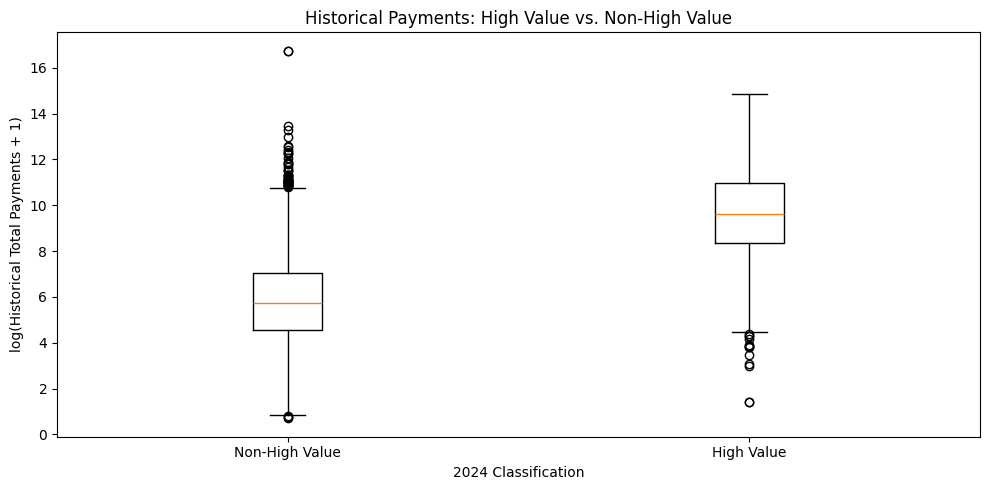

In [ ]:
# Compare historical total payments visually:
non_high_value = np.log1p(
    df.loc[
        df["high_value_2024"] == 0,
        "total_payments_2020_2023"
    ]
)

high_value = np.log1p(
    df.loc[
        df["high_value_2024"] == 1,
        "total_payments_2020_2023"
    ]
)

plt.figure(figsize=(10, 5))

plt.boxplot(
    [non_high_value, high_value],
    labels=["Non-High Value", "High Value"]
)

plt.title(
    "Historical Payments: High Value vs. Non-High Value"
)
plt.xlabel("2024 Classification")
plt.ylabel("log(Historical Total Payments + 1)")

plt.tight_layout()
plt.show()


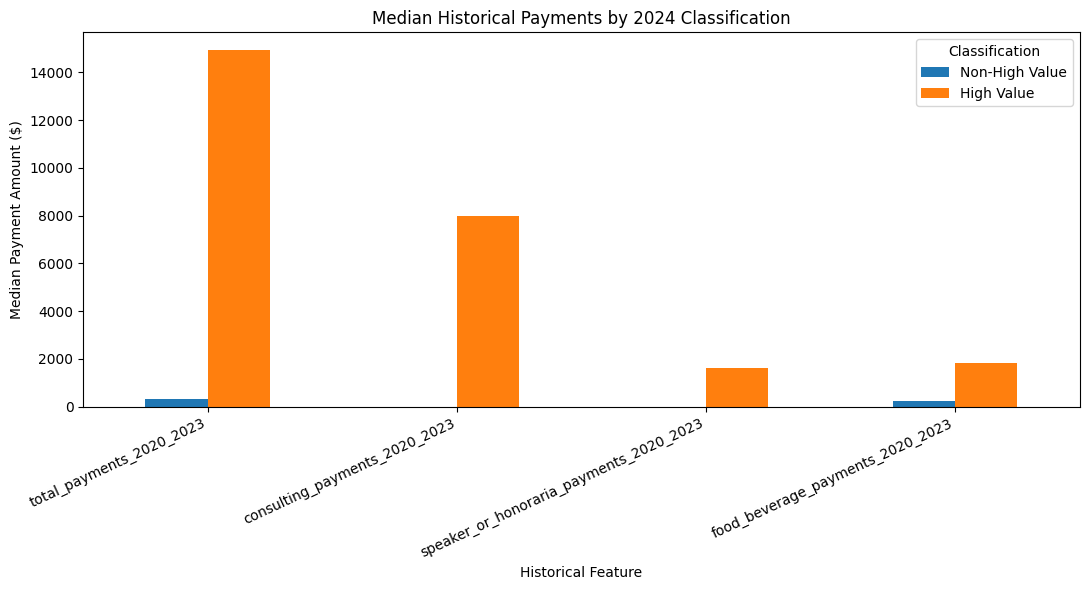

In [ ]:
# Compare median values for selected features

selected_comparison = [
    "total_payments_2020_2023",
    "consulting_payments_2020_2023",
    "speaker_or_honoraria_payments_2020_2023",
    "food_beverage_payments_2020_2023"
]

median_by_target = (
    df.groupby("high_value_2024")[selected_comparison]
    .median()
    .T
)

median_by_target.columns = [
    "Non-High Value",
    "High Value"
]

median_by_target.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title(
    "Median Historical Payments by 2024 Classification"
)
plt.xlabel("Historical Feature")
plt.ylabel("Median Payment Amount ($)")
plt.xticks(rotation=25, ha="right")
plt.legend(title="Classification")

plt.tight_layout()
plt.show()


In [ ]:
# Step 3.11 — Correlation Analysis

excluded_columns = [
    "covered_recipient_profile_id",
    "covered_recipient_npi",
    "total_payments_2024"
]

correlation_columns = [
    column
    for column in df.select_dtypes(include=np.number).columns
    if column not in excluded_columns
]

correlation_matrix = (
    df[correlation_columns]
    .corr()
)

display(correlation_matrix.round(2))


,total_payments_2020_2023,avg_annual_payments_2020_2023,max_annual_payments_2020_2023,active_years_2020_2023,total_payment_records_2020_2023,total_num_payments_reported_2020_2023,avg_unique_companies_per_year,max_unique_companies_per_year,avg_unique_payment_types_per_year,avg_unique_therapeutic_areas_per_year,avg_unique_products_per_year,consulting_payments_2020_2023,speaker_or_honoraria_payments_2020_2023,travel_lodging_payments_2020_2023,food_beverage_payments_2020_2023,consulting_payment_ratio,speaker_or_honoraria_payment_ratio,high_value_2024
total_payments_2020_2023,1.00,1.00,0.99,0.04,0.08,0.09,0.02,0.01,0.10,0.01,0.01,0.20,0.16,0.16,0.11,0.05,0.05,0.06
avg_annual_payments_2020_2023,1.00,1.00,0.99,0.03,0.08,0.08,0.02,0.01,0.10,0.01,0.01,0.22,0.16,0.16,0.11,0.06,0.05,0.07
max_annual_payments_2020_2023,0.99,0.99,1.00,0.02,0.03,0.03,0.00,0.00,0.05,-0.00,-0.00,0.08,0.06,0.06,0.04,0.02,0.02,0.03
active_years_2020_2023,0.04,0.03,0.02,1.00,0.45,0.45,0.56,0.64,0.35,0.57,0.55,0.10,0.12,0.08,0.41,0.11,0.13,0.20
total_payment_records_2020_2023,0.08,0.08,0.03,0.45,1.00,1.00,0.79,0.75,0.61,0.77,0.80,0.35,0.59,0.40,0.87,0.18,0.30,0.42
total_num_payments_reported_2020_2023,0.09,0.08,0.03,0.45,1.00,1.00,0.79,0.74,0.60,0.77,0.80,0.36,0.59,0.42,0.88,0.18,0.30,0.41
avg_unique_companies_per_year,0.02,0.02,0.00,0.56,0.79,0.79,1.00,0.97,0.45,0.98,0.99,0.09,0.17,0.11,0.69,0.03,0.13,0.26
max_unique_companies_per_year,0.01,0.01,0.00,0.64,0.75,0.74,0.97,1.00,0.44,0.96,0.95,0.08,0.16,0.10,0.65,0.03,0.12,0.24
avg_unique_payment_types_per_year,0.10,0.10,0.05,0.35,0.61,0.60,0.45,0.44,1.00,0.42,0.43,0.39,0.55,0.40,0.58,0.49,0.55,0.54
avg_unique_therapeutic_areas_per_year,0.01,0.01,-0.00,0.57,0.77,0.77,0.98,0.96,0.42,1.00,0.99,0.07,0.16,0.09,0.67,-0.01,0.12,0.23


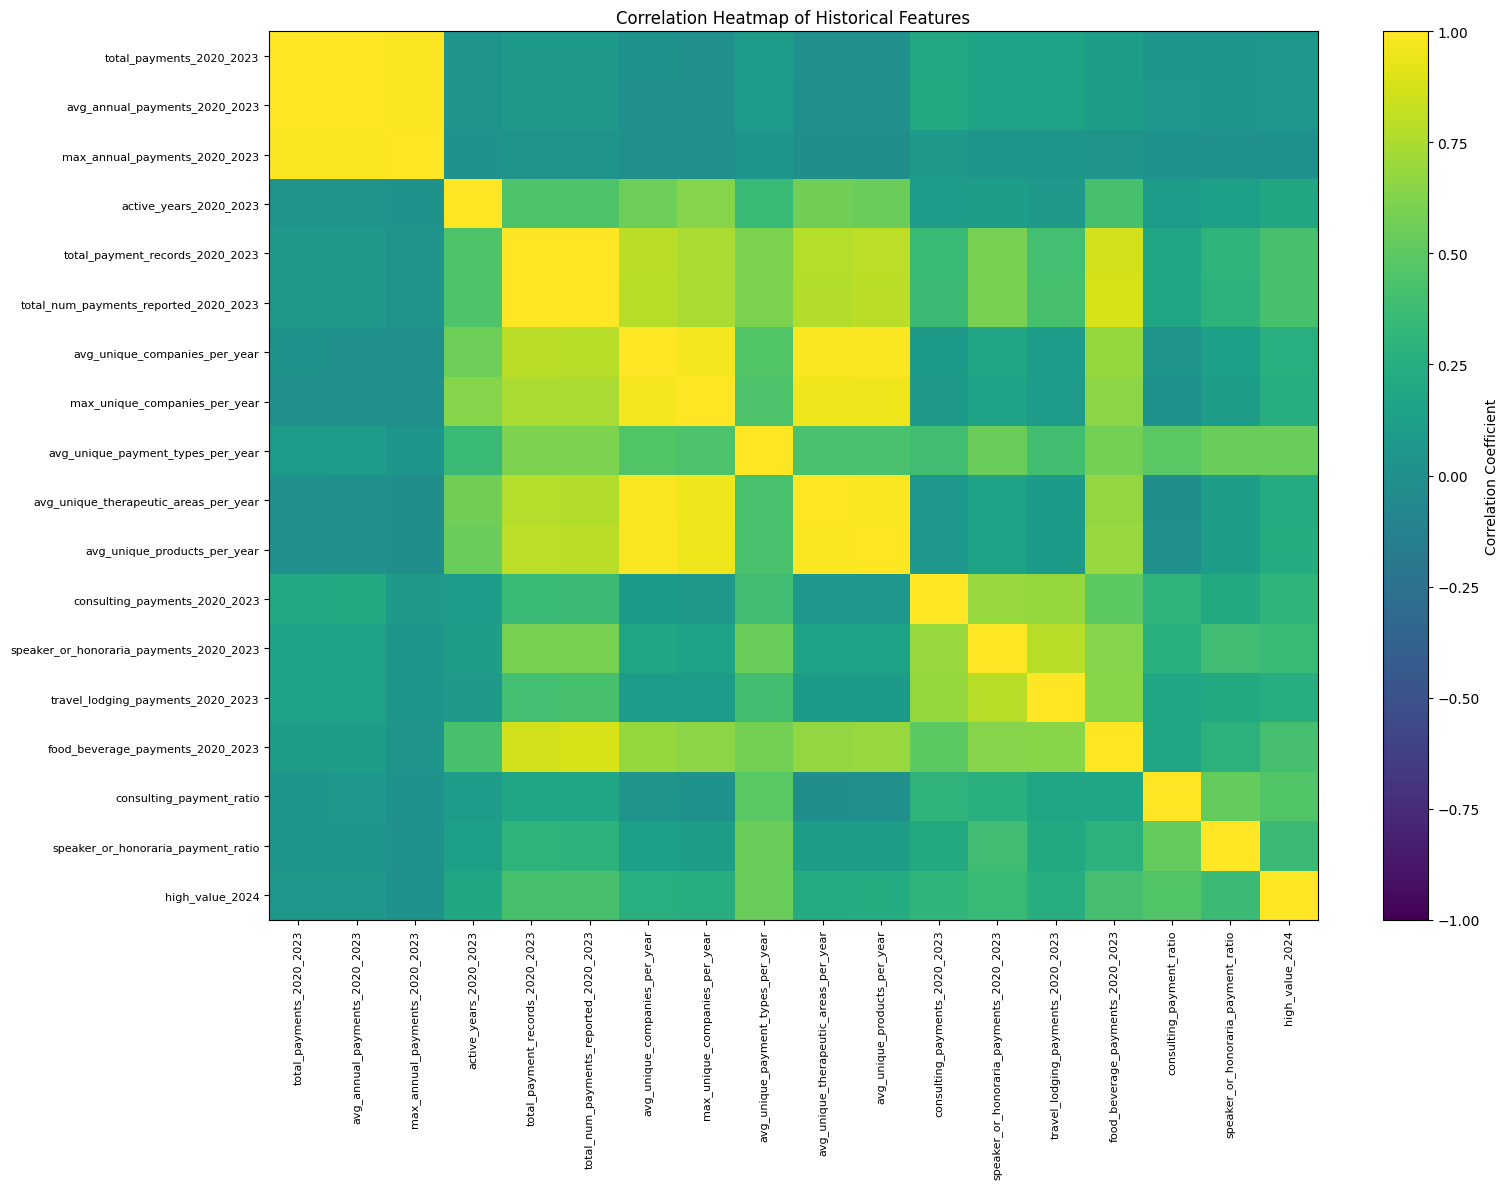

In [ ]:
# Create the heatmap
plt.figure(figsize=(16, 12))

heatmap = plt.imshow(
    correlation_matrix,
    aspect="auto",
    vmin=-1,
    vmax=1
)

plt.colorbar(
    heatmap,
    label="Correlation Coefficient"
)

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90,
    fontsize=8
)

plt.yticks(
    range(len(correlation_matrix.index)),
    correlation_matrix.index,
    fontsize=8
)

plt.title("Correlation Heatmap of Historical Features")

plt.tight_layout()
plt.show()


In [ ]:
# Features most correlated with the target
target_correlations = (
    correlation_matrix["high_value_2024"]
    .drop("high_value_2024")
    .sort_values(
        key=abs,
        ascending=False
    )
)

print("Features most strongly correlated with high_value_2024:")

display(
    target_correlations
    .to_frame("correlation_with_target")
    .round(3)
)


Features most strongly correlated with high_value_2024:


,correlation_with_target
avg_unique_payment_types_per_year,0.540
consulting_payment_ratio,0.453
total_payment_records_2020_2023,0.416
total_num_payments_reported_2020_2023,0.414
food_beverage_payments_2020_2023,0.412
speaker_or_honoraria_payment_ratio,0.365
speaker_or_honoraria_payments_2020_2023,0.346
consulting_payments_2020_2023,0.308
avg_unique_companies_per_year,0.259
travel_lodging_payments_2020_2023,0.249


,recipient_state,physician_count,percentage
0,CA,1133,10.26
1,TX,1131,10.24
2,NY,890,8.06
3,FL,644,5.83
4,PA,590,5.34
5,OH,474,4.29
6,IL,420,3.80
7,NJ,371,3.36
8,GA,353,3.20
9,NC,340,3.08


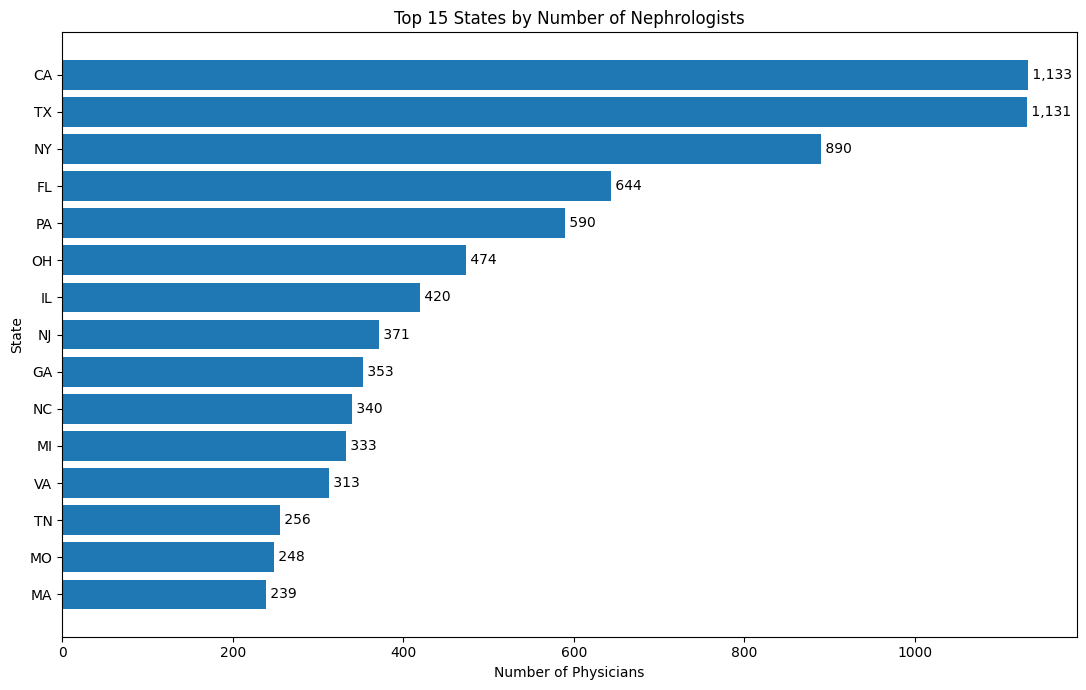

In [ ]:
# Step 3.12 — Geographic Distribution


top_states = (
    df["recipient_state"]
    .fillna("Unknown")
    .value_counts()
    .head(15)
)

top_states_table = (
    top_states
    .rename_axis("recipient_state")
    .reset_index(name="physician_count")
)

top_states_table["percentage"] = (
    top_states_table["physician_count"]
    / len(df)
    * 100
).round(2)

display(top_states_table)

plt.figure(figsize=(11, 7))

# chart
bars = plt.barh(
    top_states_table["recipient_state"][::-1],
    top_states_table["physician_count"][::-1]
)

plt.title("Top 15 States by Number of Nephrologists")
plt.xlabel("Number of Physicians")
plt.ylabel("State")

for bar, count in zip(
    bars,
    top_states_table["physician_count"][::-1]
):
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f" {count:,}",
        va="center"
    )

plt.tight_layout()
plt.show()


In [ ]:
# High-value rate by state
state_target_summary = (
    df.groupby("recipient_state")
    .agg(
        total_physicians=(
            "covered_recipient_profile_id",
            "count"
        ),
        high_value_physicians=(
            "high_value_2024",
            "sum"
        )
    )
    .reset_index()
)

state_target_summary["high_value_rate"] = (
    state_target_summary["high_value_physicians"]
    / state_target_summary["total_physicians"]
    * 100
)

# Restrict comparison to states with at least 50 physicians
state_target_summary = (
    state_target_summary[
        state_target_summary["total_physicians"] >= 50
    ]
    .sort_values(
        "high_value_rate",
        ascending=False
    )
)

display(state_target_summary.head(15).round(2))


,recipient_state,total_physicians,high_value_physicians,high_value_rate
19,MA,239,39,16.32
29,NE,57,9,15.79
23,MN,94,13,13.83
40,RI,53,6,11.32
12,IA,55,6,10.91
50,WI,139,15,10.79
5,CO,123,13,10.57
1,AL,137,14,10.22
35,OH,474,43,9.07
14,IL,420,38,9.05


,active_years,physician_count,percentage
0,1,2823,25.56
1,2,2052,18.58
2,3,1921,17.39
3,4,4248,38.46


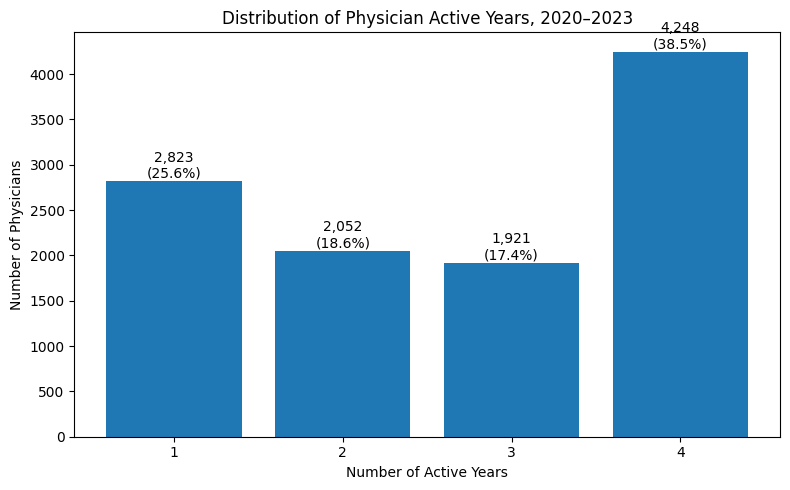

,Non-High Value %,High Value %
active_years_2020_2023,,
1,98.26,1.74
2,96.39,3.61
3,94.27,5.73
4,85.50,14.50


In [ ]:
# Step 3.13 — Active Years Distribution

active_year_counts = (
    df["active_years_2020_2023"]
    .value_counts()
    .sort_index()
)

active_year_distribution = pd.DataFrame({
    "active_years": active_year_counts.index,
    "physician_count": active_year_counts.values
})

active_year_distribution["percentage"] = (
    active_year_distribution["physician_count"]
    / len(df)
    * 100
).round(2)

display(active_year_distribution)

# Chart
plt.figure(figsize=(8, 5))

bars = plt.bar(
    active_year_distribution["active_years"].astype(str),
    active_year_distribution["physician_count"]
)

plt.title("Distribution of Physician Active Years, 2020–2023")
plt.xlabel("Number of Active Years")
plt.ylabel("Number of Physicians")

for bar, count, percentage in zip(
    bars,
    active_year_distribution["physician_count"],
    active_year_distribution["percentage"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}\n({percentage:.1f}%)",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

# Active years by target class
active_year_target = pd.crosstab(
    df["active_years_2020_2023"],
    df["high_value_2024"],
    normalize="index"
).mul(100)

active_year_target.columns = [
    "Non-High Value %",
    "High Value %"
]

display(active_year_target.round(2))


In [ ]:
# Step 3.14 — EDA Summary


total_physicians = len(df)

high_value_count = int(
    (df["high_value_2024"] == 1).sum()
)

non_high_value_count = int(
    (df["high_value_2024"] == 0).sum()
)

high_value_percentage = (
    high_value_count / total_physicians * 100
)

missing_total = int(
    df.isnull().sum().sum()
)

duplicate_physicians = int(
    df.duplicated(
        subset="covered_recipient_profile_id"
    ).sum()
)

top_state = (
    df["recipient_state"]
    .value_counts()
    .idxmax()
)

top_state_count = int(
    df["recipient_state"]
    .value_counts()
    .max()
)

most_common_active_years = (
    df["active_years_2020_2023"]
    .mode()
    .iloc[0]
)

top_correlated_feature = (
    target_correlations
    .abs()
    .idxmax()
)

top_correlation_value = (
    target_correlations[
        top_correlated_feature
    ]
)

print("EDA SUMMARY")
print("=" * 65)

print(
    f"1. The modeling dataset contains "
    f"{total_physicians:,} physicians and "
    f"{df.shape[1]} columns."
)

print(
    f"2. The target contains "
    f"{high_value_count:,} high-value physicians "
    f"({high_value_percentage:.2f}%) and "
    f"{non_high_value_count:,} non-high-value physicians."
)

print(
    f"3. The dataset contains "
    f"{missing_total:,} missing values and "
    f"{duplicate_physicians:,} duplicate physician IDs."
)

print(
    f"4. Historical payments are strongly right-skewed, "
    f"with a small group of physicians receiving substantially "
    f"larger payments than the majority."
)

print(
    f"5. The state with the greatest number of physicians is "
    f"{top_state}, with {top_state_count:,} physicians."
)

print(
    f"6. The most common historical activity period is "
    f"{most_common_active_years} active year(s) between "
    f"2020 and 2023."
)

print(
    f"7. The historical feature with the strongest linear "
    f"relationship to high_value_2024 is "
    f"{top_correlated_feature}, with a correlation of "
    f"{top_correlation_value:.3f}."
)

print(
    "8. The target is imbalanced, so accuracy alone should not "
    "be used to evaluate the machine learning models. Precision, "
    "recall, F1-score, ROC-AUC, and the confusion matrix should "
    "also be evaluated."
)

print(
    "9. total_payments_2024 must not be included as a model "
    "predictor because it directly determines high_value_2024 "
    "and would cause target leakage."
)


EDA SUMMARY
1. The modeling dataset contains 11,044 physicians and 24 columns.
2. The target contains 849 high-value physicians (7.69%) and 10,195 non-high-value physicians.
3. The dataset contains 8 missing values and 0 duplicate physician IDs.
4. Historical payments are strongly right-skewed, with a small group of physicians receiving substantially larger payments than the majority.
5. The state with the greatest number of physicians is CA, with 1,133 physicians.
6. The most common historical activity period is 4 active year(s) between 2020 and 2023.
7. The historical feature with the strongest linear relationship to high_value_2024 is avg_unique_payment_types_per_year, with a correlation of 0.540.
8. The target is imbalanced, so accuracy alone should not be used to evaluate the machine learning models. Precision, recall, F1-score, ROC-AUC, and the confusion matrix should also be evaluated.
9. total_payments_2024 must not be included as a model predictor because it directly determine

# 4. Data Preparation

This section defines the target and predictor variables, encodes categorical data, creates the train/test split, and scales numerical features where required.


In [ ]:
# Step 4.1 — Reload and Verify Modeling Dataset

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv(
    "OP_NEPHROLOGY_MODELING_DATASET_USETHIS.csv",
    encoding="utf-8-sig"
)

print("Dataset Shape:", df.shape)
display(df.head())


Dataset Shape: (11044, 24)


,covered_recipient_profile_id,covered_recipient_npi,first_name,last_name,recipient_state,total_payments_2020_2023,avg_annual_payments_2020_2023,max_annual_payments_2020_2023,active_years_2020_2023,total_payment_records_2020_2023,...,avg_unique_therapeutic_areas_per_year,avg_unique_products_per_year,consulting_payments_2020_2023,speaker_or_honoraria_payments_2020_2023,travel_lodging_payments_2020_2023,food_beverage_payments_2020_2023,consulting_payment_ratio,speaker_or_honoraria_payment_ratio,total_payments_2024,high_value_2024
0,112684,1.497713e+09,ADAM,SUN,CA,1697.41,424.3525,655.73,4,71,...,5.000000,7.750000,0.0,0.0,0.0,1638.42,0.0,0.0,772.37,0
1,112723,1.497748e+09,ABDUS,MALIK,OH,5.74,5.7400,5.74,1,2,...,0.000000,0.000000,0.0,0.0,0.0,0.00,0.0,0.0,3.08,0
2,1127509,1.831351e+09,ERNESTO,SEQUEIRA ABARCA,CA,255.38,255.3800,255.38,1,14,...,7.000000,8.000000,0.0,0.0,0.0,255.38,0.0,0.0,586.77,0
3,1128492,1.871748e+09,NORBERT,SHTAYNBERG,NY,282.96,94.3200,146.91,3,6,...,1.333333,1.333333,0.0,0.0,0.0,282.96,0.0,0.0,396.60,0
4,11286994,1.972034e+09,Gabriel,Rodriguez-Tellado,FL,124.52,124.5200,124.52,1,1,...,1.000000,1.000000,0.0,0.0,0.0,124.52,0.0,0.0,0.00,0


In [ ]:
# Step 4.2 — Inspect Columns
# View all column names

for column in df.columns:
    print(column)


covered_recipient_profile_id
covered_recipient_npi
first_name
last_name
recipient_state
total_payments_2020_2023
avg_annual_payments_2020_2023
max_annual_payments_2020_2023
active_years_2020_2023
total_payment_records_2020_2023
total_num_payments_reported_2020_2023
avg_unique_companies_per_year
max_unique_companies_per_year
avg_unique_payment_types_per_year
avg_unique_therapeutic_areas_per_year
avg_unique_products_per_year
consulting_payments_2020_2023
speaker_or_honoraria_payments_2020_2023
travel_lodging_payments_2020_2023
food_beverage_payments_2020_2023
consulting_payment_ratio
speaker_or_honoraria_payment_ratio
total_payments_2024
high_value_2024


In [ ]:
# Step 4.3 — Check Data Types
print(df.dtypes)


covered_recipient_profile_id                 int64
covered_recipient_npi                      float64
first_name                                  object
last_name                                   object
recipient_state                             object
total_payments_2020_2023                   float64
avg_annual_payments_2020_2023              float64
max_annual_payments_2020_2023              float64
active_years_2020_2023                       int64
total_payment_records_2020_2023              int64
total_num_payments_reported_2020_2023        int64
avg_unique_companies_per_year              float64
max_unique_companies_per_year                int64
avg_unique_payment_types_per_year          float64
avg_unique_therapeutic_areas_per_year      float64
avg_unique_products_per_year               float64
consulting_payments_2020_2023              float64
speaker_or_honoraria_payments_2020_2023    float64
travel_lodging_payments_2020_2023          float64
food_beverage_payments_2020_202

In [ ]:
# Step 4.4 — Define Target Variable

y = df["high_value_2024"]

print(y.value_counts())


high_value_2024
0    10195
1      849
Name: count, dtype: int64


In [ ]:
# Step 4.5 — Define Predictor Variables

# Columns excluded from modeling
exclude_cols = [

    # Physician identifiers
    "covered_recipient_profile_id",
    "covered_recipient_npi",
    "first_name",
    "last_name",

    # Future information (target leakage)
    "total_payments_2024",

    # Target variable (already assigned to y)
    "high_value_2024"
]

# Save physician identifiers for final reporting
physician_ids = df[
    [
        "covered_recipient_profile_id",
        "covered_recipient_npi",
        "first_name",
        "last_name"
    ]
].copy()

# Predictor variables
X = df.drop(columns=exclude_cols)

print("Predictor dataset shape:", X.shape)
print("Number of predictor variables:", X.shape[1])

print("\nPredictor Variables:")
display(pd.DataFrame({"Predictor": X.columns}))


Predictor dataset shape: (11044, 18)
Number of predictor variables: 18

Predictor Variables:


,Predictor
0,recipient_state
1,total_payments_2020_2023
2,avg_annual_payments_2020_2023
3,max_annual_payments_2020_2023
4,active_years_2020_2023
5,total_payment_records_2020_2023
6,total_num_payments_reported_2020_2023
7,avg_unique_companies_per_year
8,max_unique_companies_per_year
9,avg_unique_payment_types_per_year


In [ ]:
# Step 4.6 — Identify Numerical and Categorical Features

import numpy as np

numeric_features = X.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X.select_dtypes(
    exclude=np.number
).columns.tolist()

print("Numerical features:")
for column in numeric_features:
    print(f"- {column}")

print("\nCategorical features:")
for column in categorical_features:
    print(f"- {column}")

print(f"\nNumber of numerical features: {len(numeric_features)}")
print(f"Number of categorical features: {len(categorical_features)}")


Numerical features:
- total_payments_2020_2023
- avg_annual_payments_2020_2023
- max_annual_payments_2020_2023
- active_years_2020_2023
- total_payment_records_2020_2023
- total_num_payments_reported_2020_2023
- avg_unique_companies_per_year
- max_unique_companies_per_year
- avg_unique_payment_types_per_year
- avg_unique_therapeutic_areas_per_year
- avg_unique_products_per_year
- consulting_payments_2020_2023
- speaker_or_honoraria_payments_2020_2023
- travel_lodging_payments_2020_2023
- food_beverage_payments_2020_2023
- consulting_payment_ratio
- speaker_or_honoraria_payment_ratio

Categorical features:
- recipient_state

Number of numerical features: 17
Number of categorical features: 1


In [ ]:
# Step 4.7 — One-Hot Encode recipient_state

X_encoded = pd.get_dummies(
    X,
    columns=categorical_features,
    drop_first=True,
    dtype=int
)

print("Shape before encoding:", X.shape)
print("Shape after encoding :", X_encoded.shape)

print("\nFirst five encoded rows:")
display(X_encoded.head())


Shape before encoding: (11044, 18)
Shape after encoding : (11044, 69)

First five encoded rows:


,total_payments_2020_2023,avg_annual_payments_2020_2023,max_annual_payments_2020_2023,active_years_2020_2023,total_payment_records_2020_2023,total_num_payments_reported_2020_2023,avg_unique_companies_per_year,max_unique_companies_per_year,avg_unique_payment_types_per_year,avg_unique_therapeutic_areas_per_year,...,recipient_state_TN,recipient_state_TX,recipient_state_UT,recipient_state_VA,recipient_state_VI,recipient_state_VT,recipient_state_WA,recipient_state_WI,recipient_state_WV,recipient_state_WY
0,1697.41,424.3525,655.73,4,71,98,6.750000,8,1.25,5.000000,...,0,0,0,0,0,0,0,0,0,0
1,5.74,5.7400,5.74,1,2,2,1.000000,1,1.00,0.000000,...,0,0,0,0,0,0,0,0,0,0
2,255.38,255.3800,255.38,1,14,14,8.000000,8,1.00,7.000000,...,0,0,0,0,0,0,0,0,0,0
3,282.96,94.3200,146.91,3,6,6,1.333333,2,1.00,1.333333,...,0,0,0,0,0,0,0,0,0,0
4,124.52,124.5200,124.52,1,1,1,1.000000,1,1.00,1.000000,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# Check newly created state columns

state_columns = [
    column
    for column in X_encoded.columns
    if column.startswith("recipient_state_")
]

print(f"Number of encoded state columns: {len(state_columns)}")
print(state_columns)


Number of encoded state columns: 52
['recipient_state_AL', 'recipient_state_AR', 'recipient_state_AZ', 'recipient_state_CA', 'recipient_state_CO', 'recipient_state_CT', 'recipient_state_DC', 'recipient_state_DE', 'recipient_state_FL', 'recipient_state_GA', 'recipient_state_HI', 'recipient_state_IA', 'recipient_state_ID', 'recipient_state_IL', 'recipient_state_IN', 'recipient_state_KS', 'recipient_state_KY', 'recipient_state_LA', 'recipient_state_MA', 'recipient_state_MD', 'recipient_state_ME', 'recipient_state_MI', 'recipient_state_MN', 'recipient_state_MO', 'recipient_state_MS', 'recipient_state_MT', 'recipient_state_NC', 'recipient_state_ND', 'recipient_state_NE', 'recipient_state_NH', 'recipient_state_NJ', 'recipient_state_NM', 'recipient_state_NV', 'recipient_state_NY', 'recipient_state_OH', 'recipient_state_OK', 'recipient_state_OR', 'recipient_state_PA', 'recipient_state_PR', 'recipient_state_RI', 'recipient_state_SC', 'recipient_state_SD', 'recipient_state_TN', 'recipient_state_

In [ ]:
# Step 4.8 — Train/Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training predictor shape:", X_train.shape)
print("Testing predictor shape :", X_test.shape)

print("Training target shape:", y_train.shape)
print("Testing target shape :", y_test.shape)


Training predictor shape: (8835, 69)
Testing predictor shape : (2209, 69)
Training target shape: (8835,)
Testing target shape : (2209,)


In [ ]:
# Confirm target distribution was preserved

train_distribution = (
    y_train.value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

test_distribution = (
    y_test.value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

distribution_check = pd.DataFrame({
    "Training Percentage": train_distribution,
    "Testing Percentage": test_distribution
})

display(distribution_check)


,Training Percentage,Testing Percentage
high_value_2024,,
0,92.31,92.32
1,7.69,7.68


In [ ]:
# Confirm that the target distribution was preserved

train_distribution = (
    y_train.value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

test_distribution = (
    y_test.value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

distribution_check = pd.DataFrame({
    "Training Percentage": train_distribution,
    "Testing Percentage": test_distribution
})

display(distribution_check)


,Training Percentage,Testing Percentage
high_value_2024,,
0,92.31,92.3
1,7.69,7.7


In [ ]:
# Step 4.9 — Standardize Numerical Features


from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Create copies so the original train/test datasets remain unchanged
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Fit only on training numerical features
X_train_scaled[numeric_features] = scaler.fit_transform(
    X_train[numeric_features]
)

# Apply the training scaler to the test numerical features
X_test_scaled[numeric_features] = scaler.transform(
    X_test[numeric_features]
)

print("Numerical features standardized successfully.")

print("\nScaled training shape:", X_train_scaled.shape)
print("Scaled testing shape :", X_test_scaled.shape)


Numerical features standardized successfully.

Scaled training shape: (8835, 69)
Scaled testing shape : (2209, 69)


In [ ]:
# Verify scaling

scaling_check = pd.DataFrame({
    "training_mean": X_train_scaled[numeric_features].mean(),
    "training_standard_deviation":
        X_train_scaled[numeric_features].std(ddof=0)
})

display(scaling_check.round(3))


,training_mean,training_standard_deviation
total_payments_2020_2023,-0.0,1.0
avg_annual_payments_2020_2023,-0.0,1.0
max_annual_payments_2020_2023,-0.0,1.0
active_years_2020_2023,0.0,1.0
total_payment_records_2020_2023,-0.0,1.0
total_num_payments_reported_2020_2023,0.0,1.0
avg_unique_companies_per_year,0.0,1.0
max_unique_companies_per_year,-0.0,1.0
avg_unique_payment_types_per_year,-0.0,1.0
avg_unique_therapeutic_areas_per_year,0.0,1.0


# 5. Machine Learning Model Development

Four classification models were trained and evaluated: Logistic Regression, Decision Tree, Random Forest, and Gradient Boosting. Multiple algorithms were included to compare a linear baseline with tree-based and ensemble approaches and to determine which model best distinguished future high-value physicians.


## 5.1 Logistic Regression Baseline


In [ ]:
# Step 5.1 — Logistic Regression Baseline Model

import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np


df = pd.read_csv(
    "OP_NEPHROLOGY_MODELING_DATASET_USETHIS.csv",
    encoding="utf-8-sig"
)

y = df["high_value_2024"]

exclude_cols = [
    "covered_recipient_profile_id",
    "covered_recipient_npi",
    "first_name",
    "last_name",
    "total_payments_2024",
    "high_value_2024"
]

X = df.drop(columns=exclude_cols)

numeric_features = X.select_dtypes(
    include=np.number
).columns.tolist()
categorical_features = X.select_dtypes(
    exclude=np.number
).columns.tolist()

X_encoded = pd.get_dummies(
    X,
    columns=categorical_features,
    drop_first=True,
    dtype=int
)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_features] = scaler.fit_transform(
    X_train[numeric_features]
)
X_test_scaled[numeric_features] = scaler.transform(
    X_test[numeric_features]
)

# Step 3B Baseline Model - Logistic Regression
log_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

log_model.fit(
    X_train_scaled,
    y_train
)

print("Baseline Logistic Regression model trained.")


Baseline Logistic Regression model trained.


In [ ]:
# Step 5.1.1 — Logistic Regression Predictions

from sklearn.metrics import accuracy_score

y_pred = log_model.predict(X_test_scaled)

accuracy = accuracy_score(
    y_test,
    y_pred
)

print(f"Accuracy: {accuracy:.4f}")


Accuracy: 0.9502


In [ ]:
# Step 5.1.2 — Logistic Regression Classification Report

# Classification Report

from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)


              precision    recall  f1-score   support

           0       0.96      0.99      0.97      2039
           1       0.78      0.49      0.60       170

    accuracy                           0.95      2209
   macro avg       0.87      0.74      0.79      2209
weighted avg       0.95      0.95      0.95      2209



In [ ]:
# Step 5.1.3 — Logistic Regression Confusion Matrix

# Confusion Matrix

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)


[[2015   24]
 [  86   84]]


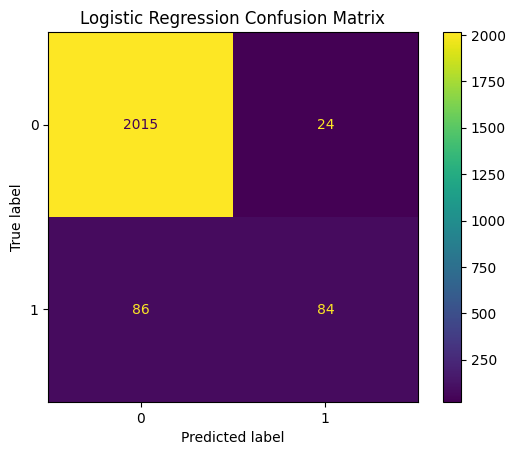

In [ ]:
# Step 5.1.4 — Logistic Regression Confusion Matrix Plot

# Confusion Matrix Plot

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(
    confusion_matrix=cm
).plot()

plt.title("Logistic Regression Confusion Matrix")

plt.show()


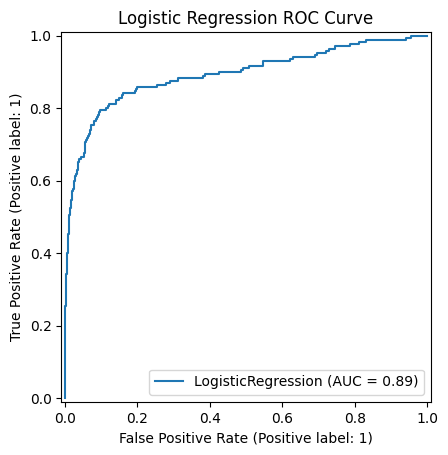

In [ ]:
# Step 5.1.5 — Logistic Regression ROC Curve

from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    log_model,
    X_test_scaled,
    y_test
)

plt.title("Logistic Regression ROC Curve")

plt.show()


In [ ]:
# Step 5.1.6 — Logistic Regression ROC-AUC

from sklearn.metrics import roc_auc_score

probabilities = log_model.predict_proba(
    X_test_scaled
)[:,1]

roc_auc = roc_auc_score(
    y_test,
    probabilities
)

print(f"ROC-AUC: {roc_auc:.4f}")


ROC-AUC: 0.8926


In [ ]:
# Logistic Regression Coefficients

coefficients = pd.DataFrame({

    "Feature": X_train.columns,

    "Coefficient": log_model.coef_[0]

})

coefficients = coefficients.sort_values(
    "Coefficient",
    key=abs,
    ascending=False
)

display(coefficients.head(20))


,Feature,Coefficient
14,food_beverage_payments_2020_2023,1.556281
46,recipient_state_NH,1.332440
64,recipient_state_VT,0.975402
2,max_annual_payments_2020_2023,-0.962726
66,recipient_state_WI,0.933381
23,recipient_state_DC,-0.855215
49,recipient_state_NV,0.844532
10,avg_unique_products_per_year,-0.834312
1,avg_annual_payments_2020_2023,0.798006
21,recipient_state_CO,0.775792


In [ ]:
# Step 5.1.7 — Logistic Regression Coefficients

coefficients = pd.DataFrame({

    "Feature": X_train.columns,

    "Coefficient": log_model.coef_[0]

})

coefficients = coefficients.sort_values(
    "Coefficient",
    key=abs,
    ascending=False
)

display(coefficients.head(20))


,Feature,Coefficient
14,food_beverage_payments_2020_2023,1.556281
46,recipient_state_NH,1.332440
64,recipient_state_VT,0.975402
2,max_annual_payments_2020_2023,-0.962726
66,recipient_state_WI,0.933381
23,recipient_state_DC,-0.855215
49,recipient_state_NV,0.844532
10,avg_unique_products_per_year,-0.834312
1,avg_annual_payments_2020_2023,0.798006
21,recipient_state_CO,0.775792


## 5.2 Decision Tree


In [ ]:
# Step 5.2.1 — Train Decision Tree

from sklearn.tree import DecisionTreeClassifier

decision_tree_model = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

decision_tree_model.fit(
    X_train,
    y_train
)

print("Decision Tree model trained successfully.")


Decision Tree model trained successfully.


In [ ]:
# Step 5.2.2 — Generate Decision Tree Predictions

decision_tree_pred = decision_tree_model.predict(X_test)

decision_tree_prob = decision_tree_model.predict_proba(
    X_test
)[:, 1]


In [ ]:
# Step 5.2.3 — Evaluate Decision Tree

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

decision_tree_accuracy = accuracy_score(
    y_test,
    decision_tree_pred
)

decision_tree_precision = precision_score(
    y_test,
    decision_tree_pred,
    zero_division=0
)

decision_tree_recall = recall_score(
    y_test,
    decision_tree_pred,
    zero_division=0
)

decision_tree_f1 = f1_score(
    y_test,
    decision_tree_pred,
    zero_division=0
)

decision_tree_roc_auc = roc_auc_score(
    y_test,
    decision_tree_prob
)

print("Decision Tree Results")
print("=" * 40)

print(f"Accuracy : {decision_tree_accuracy:.4f}")
print(f"Precision: {decision_tree_precision:.4f}")
print(f"Recall   : {decision_tree_recall:.4f}")
print(f"F1-score : {decision_tree_f1:.4f}")
print(f"ROC-AUC  : {decision_tree_roc_auc:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        decision_tree_pred,
        target_names=[
            "Non-High Value",
            "High Value"
        ],
        zero_division=0
    )
)


Decision Tree Results
Accuracy : 0.9235
Precision: 0.5028
Recall   : 0.5294
F1-score : 0.5158
ROC-AUC  : 0.7429

Classification Report:
                precision    recall  f1-score   support

Non-High Value       0.96      0.96      0.96      2039
    High Value       0.50      0.53      0.52       170

      accuracy                           0.92      2209
     macro avg       0.73      0.74      0.74      2209
  weighted avg       0.93      0.92      0.92      2209



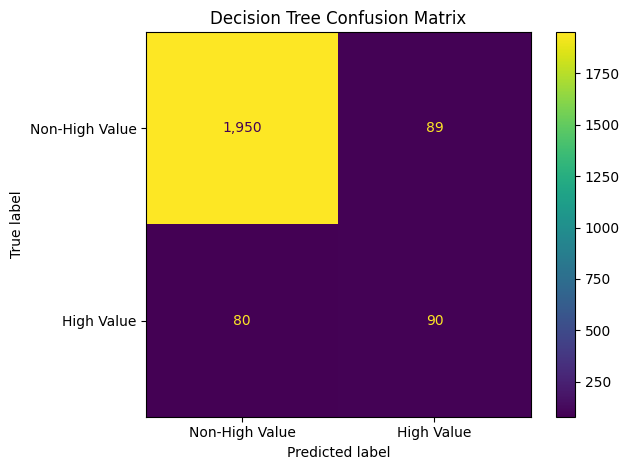

In [ ]:
# Step 5.2.4 — Decision Tree Confusion Matrix

import matplotlib.pyplot as plt

from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    decision_tree_pred,
    display_labels=[
        "Non-High Value",
        "High Value"
    ],
    values_format=","
)

plt.title("Decision Tree Confusion Matrix")
plt.tight_layout()
plt.show()


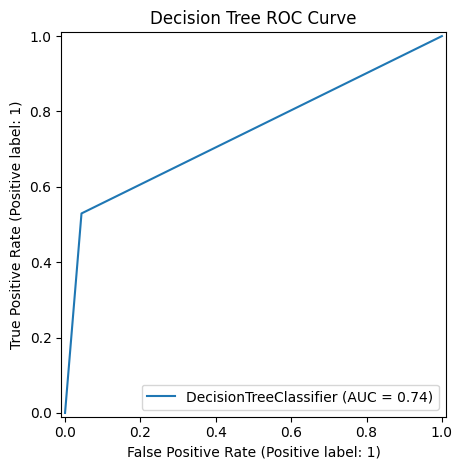

In [ ]:
# Step 5.2.5 — Decision Tree ROC Curve

from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    decision_tree_model,
    X_test,
    y_test
)

plt.title("Decision Tree ROC Curve")
plt.tight_layout()
plt.show()


## 5.3 Random Forest


In [ ]:
# Step 5.3.1 — Train Random Forest

from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

random_forest_model.fit(
    X_train,
    y_train
)

print("Random Forest model trained successfully.")


Random Forest model trained successfully.


In [ ]:
# Step 5.3.2 — Generate Random Forest Predictions

random_forest_pred = random_forest_model.predict(
    X_test
)

random_forest_prob = random_forest_model.predict_proba(
    X_test
)[:, 1]


In [ ]:
# Step 5.3.3 — Evaluate Random Forest

random_forest_accuracy = accuracy_score(
    y_test,
    random_forest_pred
)

random_forest_precision = precision_score(
    y_test,
    random_forest_pred,
    zero_division=0
)

random_forest_recall = recall_score(
    y_test,
    random_forest_pred,
    zero_division=0
)

random_forest_f1 = f1_score(
    y_test,
    random_forest_pred,
    zero_division=0
)

random_forest_roc_auc = roc_auc_score(
    y_test,
    random_forest_prob
)

print("Random Forest Results")
print("=" * 40)

print(f"Accuracy : {random_forest_accuracy:.4f}")
print(f"Precision: {random_forest_precision:.4f}")
print(f"Recall   : {random_forest_recall:.4f}")
print(f"F1-score : {random_forest_f1:.4f}")
print(f"ROC-AUC  : {random_forest_roc_auc:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        random_forest_pred,
        target_names=[
            "Non-High Value",
            "High Value"
        ],
        zero_division=0
    )
)


Random Forest Results
Accuracy : 0.9565
Precision: 0.8304
Recall   : 0.5471
F1-score : 0.6596
ROC-AUC  : 0.9025

Classification Report:
                precision    recall  f1-score   support

Non-High Value       0.96      0.99      0.98      2039
    High Value       0.83      0.55      0.66       170

      accuracy                           0.96      2209
     macro avg       0.90      0.77      0.82      2209
  weighted avg       0.95      0.96      0.95      2209



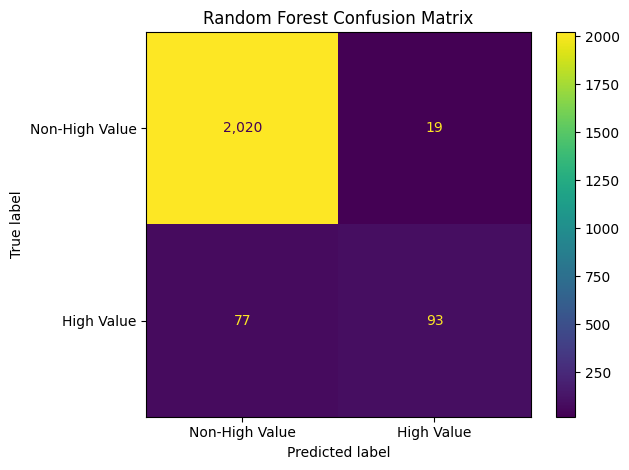

In [ ]:
# Step 5.3.4 — Random Forest Confusion Matrix

ConfusionMatrixDisplay.from_predictions(
    y_test,
    random_forest_pred,
    display_labels=[
        "Non-High Value",
        "High Value"
    ],
    values_format=","
)

plt.title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()


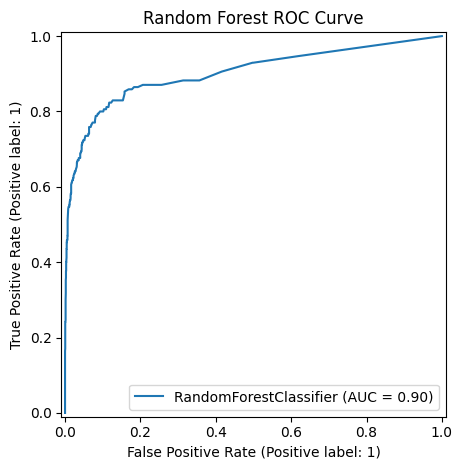

In [ ]:
# Step 5.3.5 — Random Forest ROC Curve

RocCurveDisplay.from_estimator(
    random_forest_model,
    X_test,
    y_test
)

plt.title("Random Forest ROC Curve")
plt.tight_layout()
plt.show()


## 5.4 Gradient Boosting


In [ ]:
# Step 5.4.1 — Create Balanced Sample Weights

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight

gradient_sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)


In [ ]:
# Step 5.4.2 — Train Gradient Boosting

gradient_boosting_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gradient_boosting_model.fit(
    X_train,
    y_train,
    sample_weight=gradient_sample_weights
)

print("Gradient Boosting model trained successfully.")


Gradient Boosting model trained successfully.


In [ ]:
# Step 5.4.3 — Generate Gradient Boosting Predictions

# 3E.3 Generate Predictions - Gradient Boosting

gradient_boosting_pred = gradient_boosting_model.predict(
    X_test
)

gradient_boosting_prob = (
    gradient_boosting_model.predict_proba(
        X_test
    )[:, 1]
)


In [ ]:
# Step 5.4.4 — Evaluate Gradient Boosting

gradient_boosting_accuracy = accuracy_score(
    y_test,
    gradient_boosting_pred
)

gradient_boosting_precision = precision_score(
    y_test,
    gradient_boosting_pred,
    zero_division=0
)

gradient_boosting_recall = recall_score(
    y_test,
    gradient_boosting_pred,
    zero_division=0
)

gradient_boosting_f1 = f1_score(
    y_test,
    gradient_boosting_pred,
    zero_division=0
)

gradient_boosting_roc_auc = roc_auc_score(
    y_test,
    gradient_boosting_prob
)

print("Gradient Boosting Results")
print("=" * 40)

print(f"Accuracy : {gradient_boosting_accuracy:.4f}")
print(f"Precision: {gradient_boosting_precision:.4f}")
print(f"Recall   : {gradient_boosting_recall:.4f}")
print(f"F1-score : {gradient_boosting_f1:.4f}")
print(f"ROC-AUC  : {gradient_boosting_roc_auc:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        gradient_boosting_pred,
        target_names=[
            "Non-High Value",
            "High Value"
        ],
        zero_division=0
    )
)


Gradient Boosting Results
Accuracy : 0.9072
Precision: 0.4419
Recall   : 0.7824
F1-score : 0.5648
ROC-AUC  : 0.9068

Classification Report:
                precision    recall  f1-score   support

Non-High Value       0.98      0.92      0.95      2039
    High Value       0.44      0.78      0.56       170

      accuracy                           0.91      2209
     macro avg       0.71      0.85      0.76      2209
  weighted avg       0.94      0.91      0.92      2209



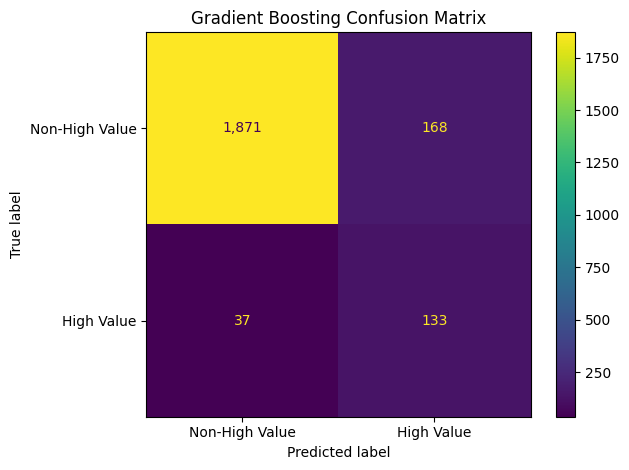

In [ ]:
# Step 5.4.5 — Gradient Boosting Confusion Matrix

ConfusionMatrixDisplay.from_predictions(
    y_test,
    gradient_boosting_pred,
    display_labels=[
        "Non-High Value",
        "High Value"
    ],
    values_format=","
)

plt.title("Gradient Boosting Confusion Matrix")
plt.tight_layout()
plt.show()


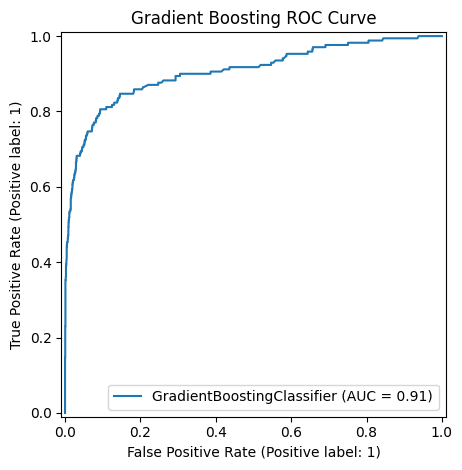

In [ ]:
# Step 5.4.6 — Gradient Boosting ROC Curve
RocCurveDisplay.from_estimator(
    gradient_boosting_model,
    X_test,
    y_test
)

plt.title("Gradient Boosting ROC Curve")
plt.tight_layout()
plt.show()


# 6. Model Evaluation

This section compares model performance using accuracy, precision, recall, F1-score, ROC-AUC, confusion matrices, and ROC curves. Because the target is imbalanced, ROC-AUC, recall, precision, and F1-score are emphasized rather than accuracy alone. The final model is selected based on its overall discrimination and its balance between identifying high-value physicians and limiting false-positive predictions.


In [ ]:
# Step 6.1 — Store Logistic Regression Metrics


logistic_pred = log_model.predict(
    X_test_scaled
)

logistic_prob = log_model.predict_proba(
    X_test_scaled
)[:, 1]

logistic_accuracy = accuracy_score(
    y_test,
    logistic_pred
)

logistic_precision = precision_score(
    y_test,
    logistic_pred,
    zero_division=0
)

logistic_recall = recall_score(
    y_test,
    logistic_pred,
    zero_division=0
)

logistic_f1 = f1_score(
    y_test,
    logistic_pred,
    zero_division=0
)

logistic_roc_auc = roc_auc_score(
    y_test,
    logistic_prob
)


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Gradient Boosting,0.9072,0.4419,0.7824,0.5648,0.9068
1,Random Forest,0.9565,0.8304,0.5471,0.6596,0.9025
2,Logistic Regression,0.9502,0.7778,0.4941,0.6043,0.8926
3,Decision Tree,0.9235,0.5028,0.5294,0.5158,0.7429


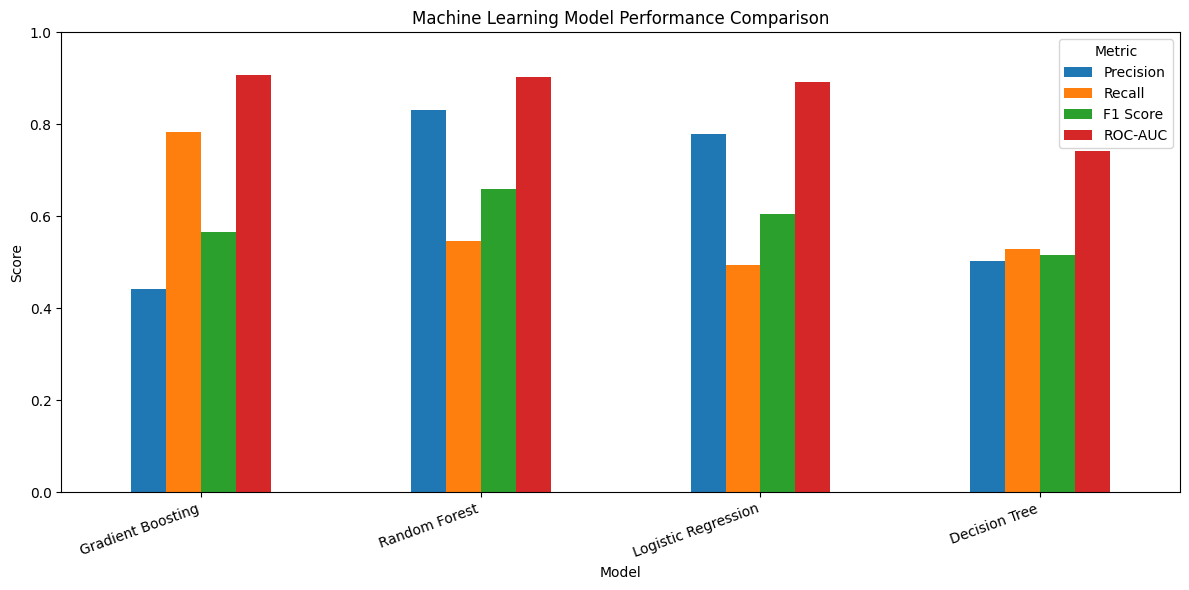

In [ ]:
# Step 6.2 — Model Performance Comparison

model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],

    "Accuracy": [
        logistic_accuracy,
        decision_tree_accuracy,
        random_forest_accuracy,
        gradient_boosting_accuracy
    ],

    "Precision": [
        logistic_precision,
        decision_tree_precision,
        random_forest_precision,
        gradient_boosting_precision
    ],

    "Recall": [
        logistic_recall,
        decision_tree_recall,
        random_forest_recall,
        gradient_boosting_recall
    ],

    "F1 Score": [
        logistic_f1,
        decision_tree_f1,
        random_forest_f1,
        gradient_boosting_f1
    ],

    "ROC-AUC": [
        logistic_roc_auc,
        decision_tree_roc_auc,
        random_forest_roc_auc,
        gradient_boosting_roc_auc
    ]
})

model_results = model_results.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

display(
    model_results.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1 Score": "{:.4f}",
        "ROC-AUC": "{:.4f}"
    })
)

comparison_plot = model_results.set_index("Model")[
    [
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
]

comparison_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Machine Learning Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.legend(title="Metric")
plt.tight_layout()
plt.show()


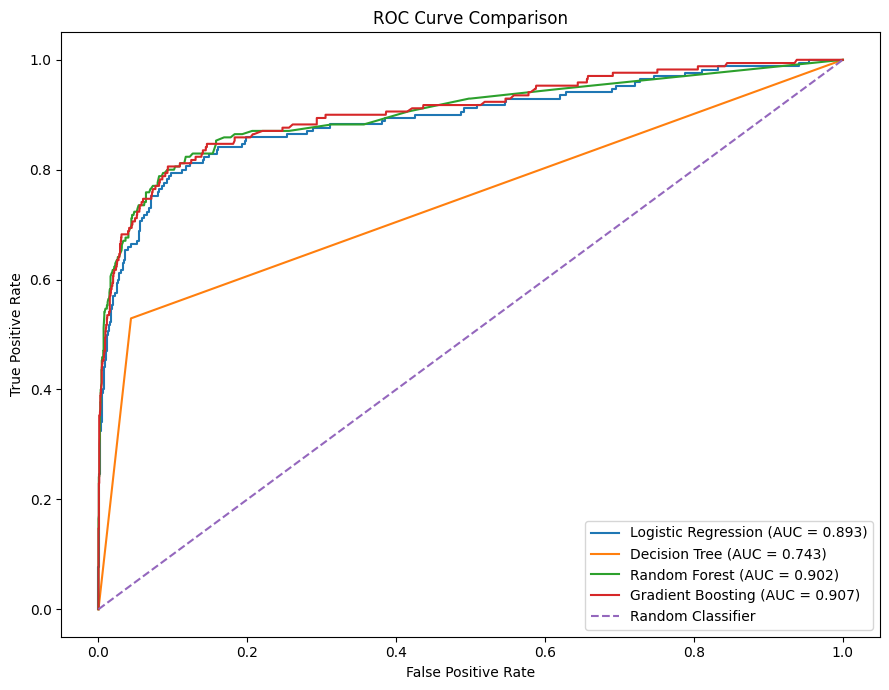

In [ ]:
# Step 6.3 — Combined ROC Curve Comparison


from sklearn.metrics import roc_curve

plt.figure(figsize=(9, 7))

model_probability_results = {
    "Logistic Regression": logistic_prob,
    "Decision Tree": decision_tree_prob,
    "Random Forest": random_forest_prob,
    "Gradient Boosting": gradient_boosting_prob
}

for model_name, probabilities in model_probability_results.items():

    false_positive_rate, true_positive_rate, _ = roc_curve(
        y_test,
        probabilities
    )

    model_auc = roc_auc_score(
        y_test,
        probabilities
    )

    plt.plot(
        false_positive_rate,
        true_positive_rate,
        label=f"{model_name} (AUC = {model_auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


In [ ]:
# Compare predictions vs actual 2024 outcomes - Inspect highest-ranked physicians
# Top predicted physicians
validation_df.head(20)


,predicted_probability,actual_high_value_2024,covered_recipient_profile_id,covered_recipient_npi,first_name,last_name,recipient_state
7552,0.996608,0,362632,1.992795e+09,ANA,STANKOVIC,NH
7549,0.996524,1,362147,1.962588e+09,MOHAMMED,AHMED,IL
4223,0.996372,1,323879,1.154368e+09,GERMAN,HERNANDEZ,TX
877,0.996369,1,105619,1.346215e+09,JORGE,LARRANAGA,FL
3299,0.996102,1,114612,1.528021e+09,JOSEPH,ROGLIERI,NY
722,0.996028,1,1112597,1.285839e+09,SALVATORE,CHILLEMI,GA
7391,0.995999,1,323948,1.154334e+09,CARL,DUKES,TX
1432,0.995910,1,152360,1.376533e+09,MICHAEL,GERMAIN,MA
967,0.995878,1,113039,1.487685e+09,LUIS,ALVAREZ,CA
2898,0.995559,1,158060,1.497791e+09,ARNOLD,SYLVIA,ID


In [ ]:
# Select the best model
# ============================================================
# Step 6.4 — Final Model Selection
# ============================================================

best_model_name = model_results.loc[
    0,
    "Model"
]

best_model_roc_auc = model_results.loc[
    0,
    "ROC-AUC"
]

best_model_f1 = model_results.loc[
    0,
    "F1 Score"
]

best_model_recall = model_results.loc[
    0,
    "Recall"
]

print("Best model based on ROC-AUC")
print("=" * 40)

print(f"Model   : {best_model_name}")
print(f"ROC-AUC : {best_model_roc_auc:.4f}")
print(f"F1-score: {best_model_f1:.4f}")
print(f"Recall  : {best_model_recall:.4f}")


Best model based on ROC-AUC
Model   : Gradient Boosting
ROC-AUC : 0.9068
F1-score: 0.5648
Recall  : 0.7824


In [ ]:
# Step 6.5 — Gradient Boosting Feature Importance

gradient_boosting_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": gradient_boosting_model.feature_importances_
})

gradient_boosting_importance = (
    gradient_boosting_importance
    .sort_values(
        by="Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

print("Top 20 Gradient Boosting Features:")
display(gradient_boosting_importance.head(20))


Top 20 Gradient Boosting Features:


,Feature,Importance
0,max_annual_payments_2020_2023,0.642113
1,avg_annual_payments_2020_2023,0.189964
2,total_payments_2020_2023,0.050130
3,consulting_payment_ratio,0.018295
4,food_beverage_payments_2020_2023,0.016508
5,speaker_or_honoraria_payment_ratio,0.010835
6,avg_unique_therapeutic_areas_per_year,0.008211
7,consulting_payments_2020_2023,0.007380
8,travel_lodging_payments_2020_2023,0.006580
9,total_payment_records_2020_2023,0.005826


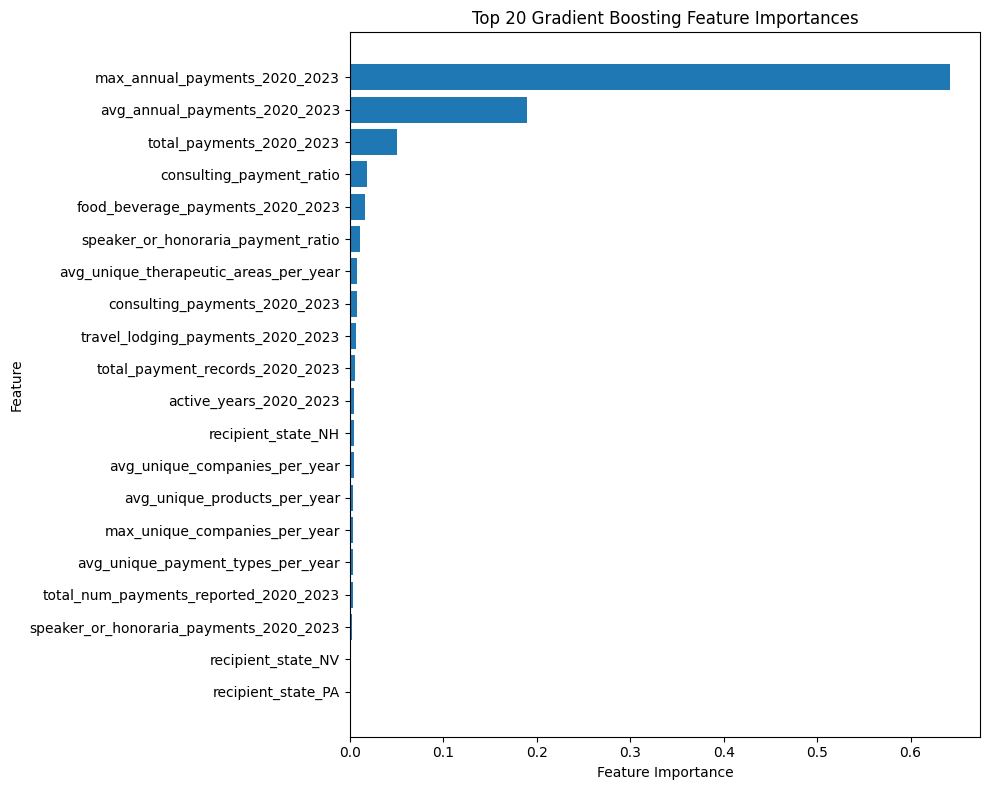

In [ ]:
# Plot the 20 most important features

top_gradient_features = (
    gradient_boosting_importance
    .head(20)
    .sort_values(
        by="Importance",
        ascending=True
    )
)

plt.figure(figsize=(10, 8))

plt.barh(
    top_gradient_features["Feature"],
    top_gradient_features["Importance"]
)

plt.title("Top 20 Gradient Boosting Feature Importances")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()


# 7. Prediction Validation

This section evaluates how well the selected model ranks physicians and identifies those who were actually classified as high value in 2024. The analysis includes top-decile lift, Precision@100, ranking validation at the actual positive count, and physician-level prediction outcomes.


In [ ]:
# Step 7.1 — Generate Final Physician Predictions

best_prediction_probabilities = gradient_boosting_prob
best_predictions = gradient_boosting_pred

test_physician_ids = physician_ids.loc[
    X_test.index
].copy()

final_predictions = test_physician_ids.copy()

final_predictions["actual_high_value_2024"] = (
    y_test.values
)

final_predictions["predicted_high_value_2024"] = (
    best_predictions
)

final_predictions["predicted_probability"] = (
    best_prediction_probabilities
)

final_predictions = final_predictions.sort_values(
    by="predicted_probability",
    ascending=False
)

display(
    final_predictions.head(30)
)


,covered_recipient_profile_id,covered_recipient_npi,first_name,last_name,actual_high_value_2024,predicted_high_value_2024,predicted_probability
7869,54629,1.215156e+09,SREEDHARA,ALLA,1,1,0.993115
9897,96528,1.124081e+09,Jeffrey,Feldman,1,1,0.988596
7549,362147,1.962588e+09,MOHAMMED,AHMED,1,1,0.988385
722,1112597,1.285839e+09,SALVATORE,CHILLEMI,1,1,0.988013
877,105619,1.346215e+09,JORGE,LARRANAGA,1,1,0.987256
10606,90103,1.992018e+09,GATES,COLBERT,1,1,0.987256
7391,323948,1.154334e+09,CARL,DUKES,1,1,0.987256
3299,114612,1.528021e+09,JOSEPH,ROGLIERI,1,1,0.987256
1432,152360,1.376533e+09,MICHAEL,GERMAIN,1,1,0.987256
4223,323879,1.154368e+09,GERMAN,HERNANDEZ,1,1,0.987256


In [ ]:
# Step 7.2 — Top-Decile Lift Analysis

validation_df = final_predictions.sort_values(
    by="predicted_probability",
    ascending=False
)

top_10_percent = int(len(validation_df) * 0.10)

top_decile = validation_df.head(top_10_percent)

top_decile_positive_rate = (
    top_decile["actual_high_value_2024"]
    .mean()
)

overall_positive_rate = (
    validation_df["actual_high_value_2024"]
    .mean()
)

lift = (
    top_decile_positive_rate
    / overall_positive_rate
)

print("=" * 45)
print("TOP DECILE VALIDATION")
print("=" * 45)

print(f"Top decile physicians: {top_10_percent:,}")

print(
    f"Top decile positive rate: "
    f"{top_decile_positive_rate:.4f}"
)

print(
    f"Overall positive rate: "
    f"{overall_positive_rate:.4f}"
)

print(
    f"Lift: {lift:.2f}x"
)


TOP DECILE VALIDATION
Top decile physicians: 220
Top decile positive rate: 0.5455
Overall positive rate: 0.0770
Lift: 7.09x


In [ ]:
# Step 7.3 — Precision@100

def precision_at_k(validation_df, k):

    top_k = validation_df.head(k)

    precision = (
        top_k["actual_high_value_2024"]
        .mean()
    )

    positives = (
        top_k["actual_high_value_2024"]
        .sum()
    )

    print(f"Precision@{k}")
    print("-" * 30)
    print(f"High-value physicians: {positives}")
    print(f"Precision: {precision:.4f}")

precision_at_k(validation_df, 100)


Precision@100
------------------------------
High-value physicians: 82
Precision: 0.8200


In [ ]:
# Step 7.4 — Ranking Validation Against Actual 2024 High-Value Physicians

# Sort physicians by predicted probability
validation_df = final_predictions.sort_values(
    by="predicted_probability",
    ascending=False
)

# Number of actual high-value physicians
actual_high_value = (
    validation_df["actual_high_value_2024"] == 1
).sum()

# Select the same number of highest-ranked physicians
predicted_top = validation_df.head(actual_high_value)

# Calculate ranking performance
correct_predictions = (
    predicted_top["actual_high_value_2024"] == 1
).sum()

capture_rate = (
    correct_predictions / actual_high_value
)

precision_at_actual = (
    predicted_top["actual_high_value_2024"]
    .mean()
)

print("=" * 55)
print("RANKING VALIDATION AGAINST ACTUAL 2024 HIGH-VALUE PHYSICIANS")
print("=" * 55)

print(f"Total physicians evaluated           : {len(validation_df):,}")
print(f"Actual high-value physicians (2024)  : {actual_high_value:,}")
print(f"Top physicians selected by model     : {actual_high_value:,}")

print()

print(f"Correctly identified high-value physicians : {correct_predictions:,}")
print(f"Capture Rate (Recall@TopN)                : {capture_rate:.2%}")
print(f"Precision@TopN                            : {precision_at_actual:.2%}")


RANKING VALIDATION AGAINST ACTUAL 2024 HIGH-VALUE PHYSICIANS
Total physicians evaluated           : 2,209
Actual high-value physicians (2024)  : 170
Top physicians selected by model     : 170

Correctly identified high-value physicians : 111
Capture Rate (Recall@TopN)                : 65.29%
Precision@TopN                            : 65.29%


In [ ]:
# Step 7.5 — Build Prediction Outcome Validation Table

# Create a validation table
validation_df = final_predictions.copy()


In [ ]:
# Step 7.5.1 — Classify Prediction Outcomes

# Classify every prediction, Prediction Outcome Analysis

validation_df["prediction_result"] = np.where(

    (validation_df["predicted_high_value_2024"] == 1) &
    (validation_df["actual_high_value_2024"] == 1),

    "True Positive",

    np.where(

        (validation_df["predicted_high_value_2024"] == 1) &
        (validation_df["actual_high_value_2024"] == 0),

        "False Positive",

        np.where(

            (validation_df["predicted_high_value_2024"] == 0) &
            (validation_df["actual_high_value_2024"] == 1),

            "False Negative",

            "True Negative"

        )
    )
)

display(validation_df.head())


,covered_recipient_profile_id,covered_recipient_npi,first_name,last_name,actual_high_value_2024,predicted_high_value_2024,predicted_probability,prediction_result
7869,54629,1.215156e+09,SREEDHARA,ALLA,1,1,0.993115,True Positive
9897,96528,1.124081e+09,Jeffrey,Feldman,1,1,0.988596,True Positive
7549,362147,1.962588e+09,MOHAMMED,AHMED,1,1,0.988385,True Positive
722,1112597,1.285839e+09,SALVATORE,CHILLEMI,1,1,0.988013,True Positive
877,105619,1.346215e+09,JORGE,LARRANAGA,1,1,0.987256,True Positive


In [ ]:
# Step 7.5.2 — Correctly Predicted High-Value Physicians

# Physicians correctly predicted
correct_predictions = validation_df[
    validation_df["prediction_result"] == "True Positive"
]

display(correct_predictions.head(100))


,covered_recipient_profile_id,covered_recipient_npi,first_name,last_name,actual_high_value_2024,predicted_high_value_2024,predicted_probability,prediction_result
7869,54629,1.215156e+09,SREEDHARA,ALLA,1,1,0.993115,True Positive
9897,96528,1.124081e+09,Jeffrey,Feldman,1,1,0.988596,True Positive
7549,362147,1.962588e+09,MOHAMMED,AHMED,1,1,0.988385,True Positive
722,1112597,1.285839e+09,SALVATORE,CHILLEMI,1,1,0.988013,True Positive
877,105619,1.346215e+09,JORGE,LARRANAGA,1,1,0.987256,True Positive
...,...,...,...,...,...,...,...,...
8241,791435,1.033520e+09,OSAMA,EL SHAMY,1,1,0.912474,True Positive
9958,7218204,1.851735e+09,REBECCA,AHDOOT,1,1,0.912470,True Positive
7413,317466,1.003015e+09,PIETRO,CANETTA,1,1,0.906048,True Positive
5246,409932,1.649334e+09,LAURA,MARIANI,1,1,0.905752,True Positive


In [ ]:
# Step 7.5.3 — Prediction Outcome Summary

# Summary of Prediction vs Result

summary = (
    validation_df["prediction_result"]
    .value_counts()
    .rename_axis("Prediction Result")
    .reset_index(name="Physicians")
)

display(summary)


,Prediction Result,Physicians
0,True Negative,1871
1,False Positive,168
2,True Positive,133
3,False Negative,37


In [ ]:
# Step 7.5.4 — Missed High-Value Physicians

# Physicians the model missed
missed_predictions = validation_df[
    validation_df["prediction_result"] == "False Negative"
]

display(missed_predictions.head(100))


,covered_recipient_profile_id,covered_recipient_npi,first_name,last_name,actual_high_value_2024,predicted_high_value_2024,predicted_probability,prediction_result
4170,266577,1.881648e+09,George,Hart,1,0,0.465511,False Negative
6575,11418618,1.477058e+09,JONATHAN,SUNG,1,0,0.452069,False Negative
3947,232481,1.134158e+09,FAWAD,AHMED,1,0,0.434129,False Negative
4388,270543,1.952469e+09,PARESH,JADAV,1,0,0.421377,False Negative
2088,1279,1.013923e+09,Uday,Nori,1,0,0.342149,False Negative
9700,967063,1.205830e+09,JAMES,SLOAND,1,0,0.296262,False Negative
9835,99023,1.174509e+09,WESLEY,CALHOUN,1,0,0.287434,False Negative
3123,187715,1.124119e+09,COURAGE,ATEKHA,1,0,0.267799,False Negative
3267,245438,1.417171e+09,HAROLD,HUBERT,1,0,0.262162,False Negative
6237,1207390,1.649447e+09,EMAD,SEDKI,1,0,0.254052,False Negative


In [ ]:
# Step 7.5.5 — False-Positive Physicians


# Physicians incorrectly predicted
false_positive_predictions = validation_df[
    validation_df["prediction_result"] == "False Positive"
]

display(false_positive_predictions.head(100))


,covered_recipient_profile_id,covered_recipient_npi,first_name,last_name,actual_high_value_2024,predicted_high_value_2024,predicted_probability,prediction_result
7552,362632,1.992795e+09,ANA,STANKOVIC,0,1,0.982183,False Positive
917,1096761,1.750585e+09,SHINA,MENON,0,1,0.968415,False Positive
3234,226890,1.003894e+09,Holly,Kramer,0,1,0.958763,False Positive
10383,91593,1.023138e+09,ARSHDEEP,TINDNI,0,1,0.957727,False Positive
4854,29407,1.649261e+09,David,Charytan,0,1,0.956737,False Positive
...,...,...,...,...,...,...,...,...
3198,190585,1.215052e+09,ALI,KHAN,0,1,0.741548,False Positive
4483,313312,1.912944e+09,VISHNU,PATEL,0,1,0.740231,False Positive
10725,6963870,1.346651e+09,Chi,Chu,0,1,0.740221,False Positive
8003,8924500,1.639532e+09,JUDITH,MADDATU,0,1,0.739259,False Positive


# 8. Results and Discussion

Gradient Boosting achieved the strongest overall discrimination, with a ROC-AUC of **0.9068**, and was selected as the final model because it provided the best overall balance of ROC-AUC, recall, and F1-score. It identified **78.24%** of high-value physicians in the test set. Its precision of **44.19%** indicates that the model also generated false-positive predictions, which is important when interpreting its use.

The ranking results provide additional practical context. Among the top 10% of physicians ranked by predicted probability, **54.55%** were actually high value, compared with an overall positive rate of **7.70%**, producing a lift of **7.09x**. Precision@100 was **82.00%**, meaning that 82 of the 100 highest-ranked test-set physicians were actual high-value physicians.

When the model selected the same number of physicians as the number of actual high-value cases in the test set, it captured **111 of 170 physicians**, for a capture rate of **65.29%**. These findings suggest that the model is most appropriate as a ranking and prioritization tool for further review rather than as a fully automated decision system.

Historical payment activity, consulting payments, payment frequency, active years, and the breadth of physician–industry relationships were among the most informative predictors of future high-value physician status. These relationships should be interpreted as predictive associations rather than evidence of causation.


# 9. Conclusion

Historical CMS Open Payments activity from 2020–2023 provided meaningful predictive information about which nephrologists would receive high-value industry payments in 2024. Gradient Boosting produced the strongest overall performance among the evaluated models and demonstrated strong ranking ability.

The project answered the research question by showing that prior payment behavior and physician–industry relationship patterns can help distinguish physicians who later became high value. At the same time, the model's false-positive predictions show that it should support—not replace—professional review and other sources of physician information.

The analysis is limited to nephrologists, CMS General Payments, and one prediction period. It does not include clinical activity, research payments, ownership interests, or internal CRM information. Future work could evaluate the methodology in other specialties and with later CMS Open Payments releases, including 2025 data when complete records become publicly available.
